<a href="https://colab.research.google.com/github/isaacadebayo/Predictive_Analytics_and_NLP/blob/main/Diabetes_Prediction_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
data = pd.read_csv('/content/drive/MyDrive/diabetes.csv')
data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
data.shape

(768, 9)

In [4]:
data.isna().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


EDA for Numerical Features (data_num):


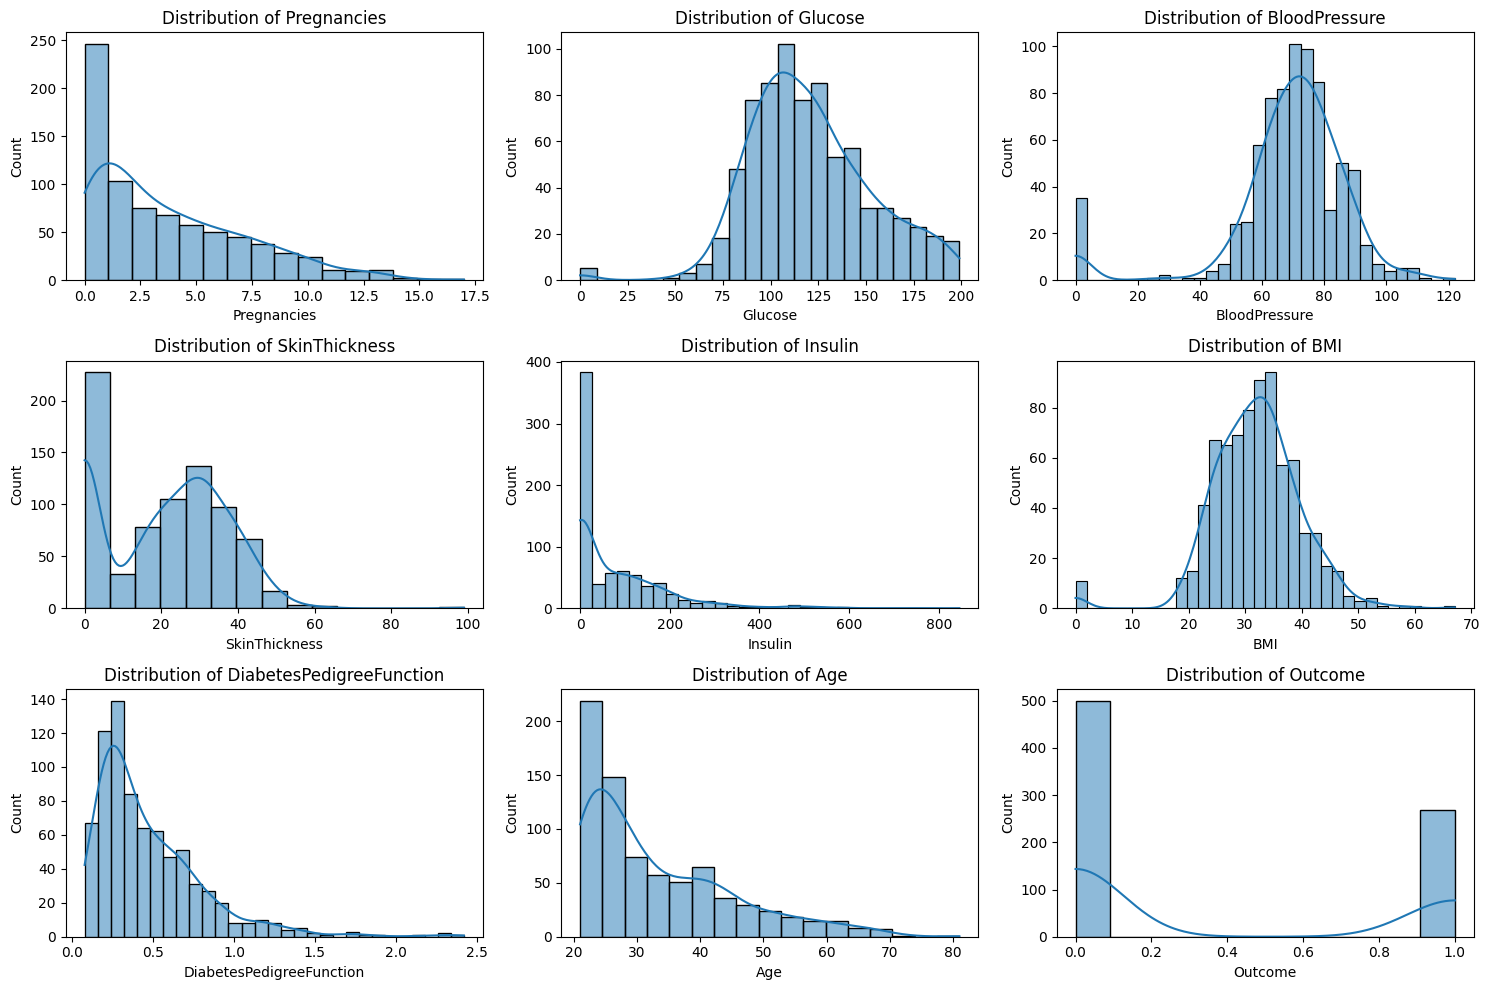

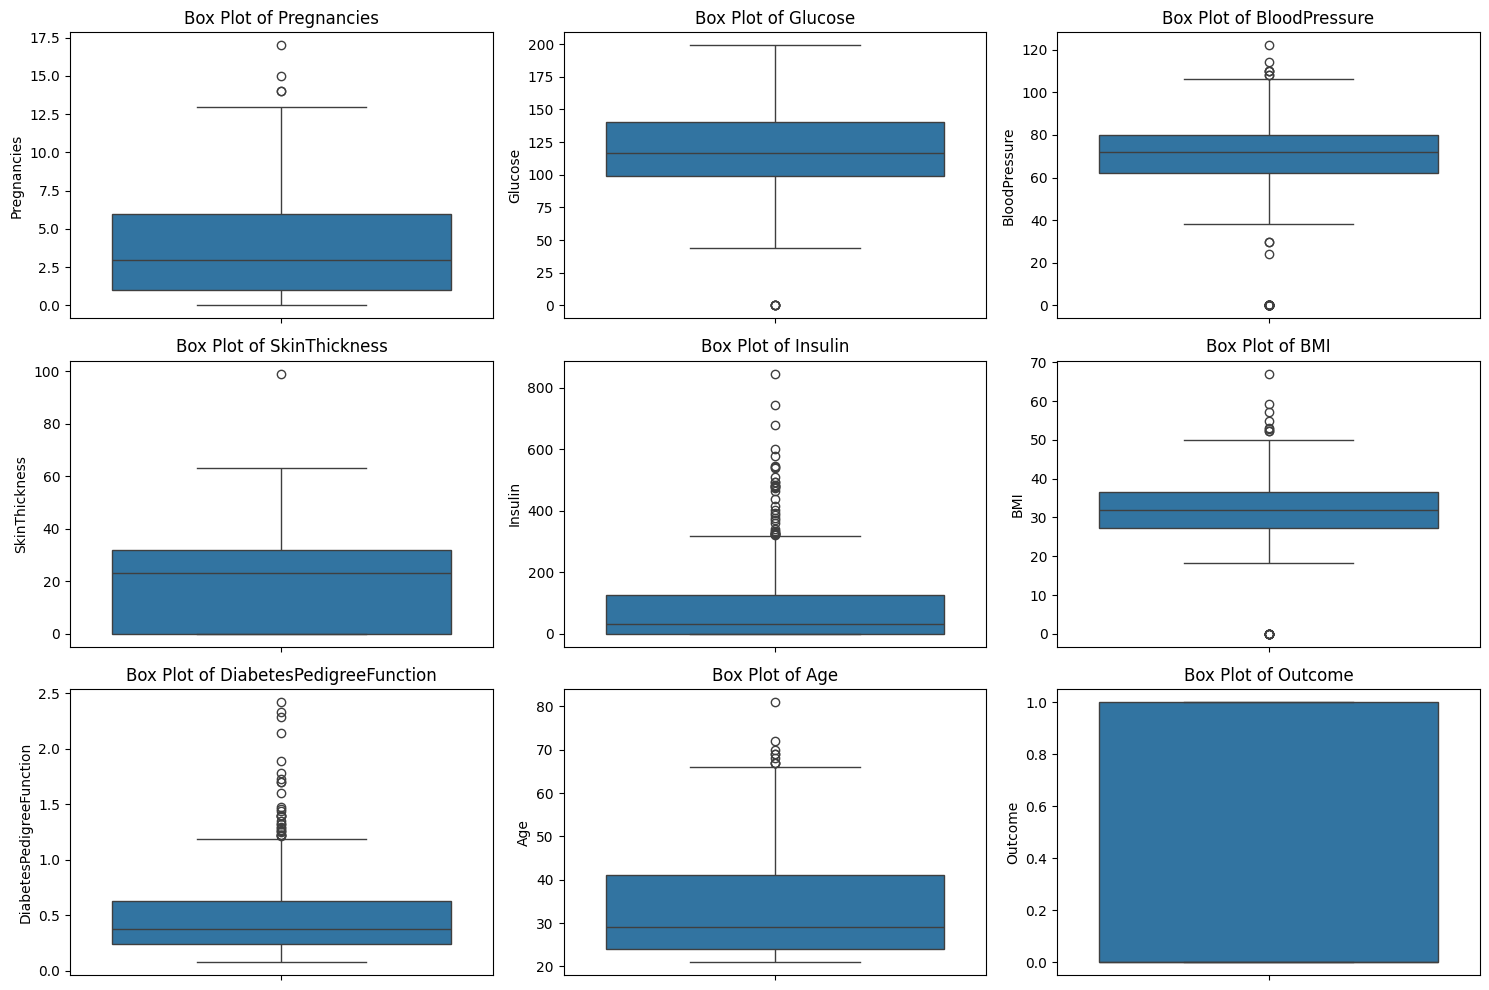

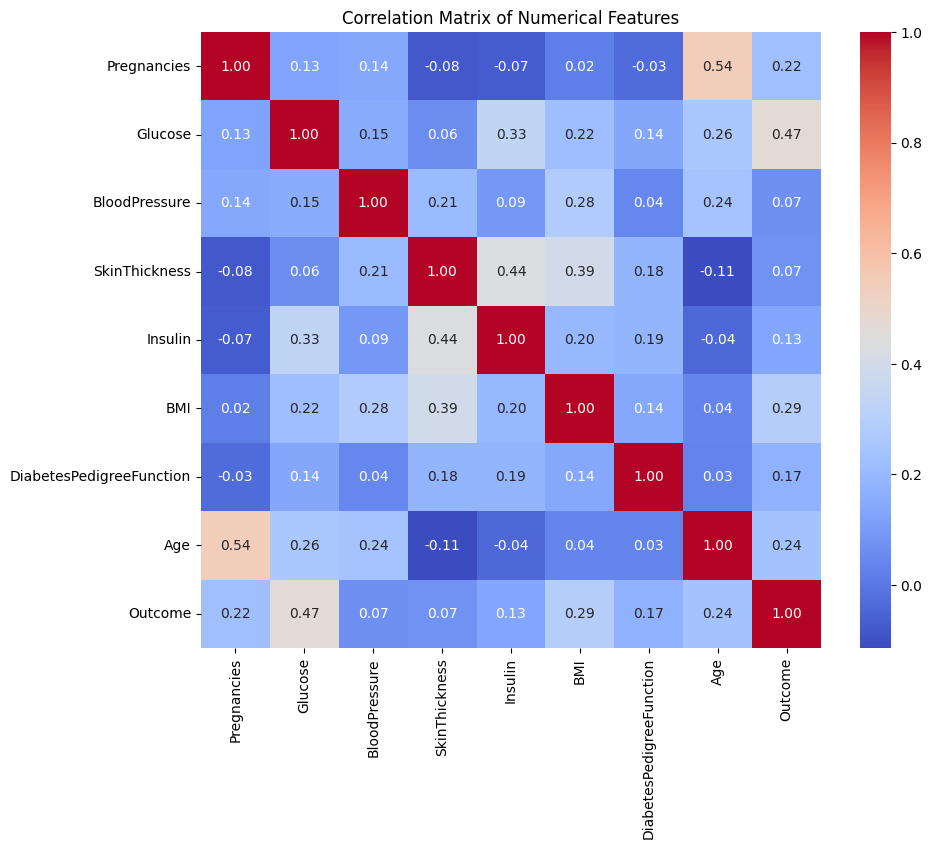

"\nprint('\nEDA for Categorical Features (data_cat):')\n# Count plots for categorical features\nplt.figure(figsize=(25, 10))\nfor i, column in enumerate(eda_cat.columns):\n    plt.subplot(1, 7, i + 1) # Adjust subplot grid based on number of columns\n    sns.countplot(y=eda_cat[column], order = eda_cat[column].value_counts().index)\n    plt.title(f'Count of {column}')\n    plt.tight_layout()\nplt.show()"

In [6]:
print('EDA for Numerical Features (data_num):')

eda_num = data.select_dtypes(exclude=object)
#eda_cat = data.select_dtypes(include=object)

# Histograms for numerical features
plt.figure(figsize=(15, 10))
for i, column in enumerate(eda_num.columns):
    plt.subplot(3, 3, i + 1) # Adjust subplot grid based on number of columns
    sns.histplot(eda_num[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.tight_layout()
plt.show()

# Box plots for numerical features
plt.figure(figsize=(15, 10))
for i, column in enumerate(eda_num.columns):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=eda_num[column])
    plt.title(f'Box Plot of {column}')
    plt.tight_layout()
plt.show()

# Correlation Matrix for numerical features
plt.figure(figsize=(10, 8))
sns.heatmap(eda_num.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

'''
print('\nEDA for Categorical Features (data_cat):')
# Count plots for categorical features
plt.figure(figsize=(25, 10))
for i, column in enumerate(eda_cat.columns):
    plt.subplot(1, 7, i + 1) # Adjust subplot grid based on number of columns
    sns.countplot(y=eda_cat[column], order = eda_cat[column].value_counts().index)
    plt.title(f'Count of {column}')
    plt.tight_layout()
plt.show()'''

There are no object so no need to exclude object but useful to know when there is a categorical variable like gender

In [7]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)


In [9]:
'''from sklearn.preprocessing import MinMaxScaler, StandardScaler

#minmax_scaler = MinMaxScaler()
std_scaler = StandardScaler()

# Apply StandardScaler to selected numerical feature columns
X_train_num = pd.DataFrame(
    std_scaler.fit_transform(X_train[X.columns]),
    columns=X.columns,
    index=X_train.index
)
X_test_num = pd.DataFrame(
    std_scaler.transform(X_test[X.columns]),   # transform only — no fit
    columns=X.columns,
    index=X_test.index
)
#end'''

'from sklearn.preprocessing import MinMaxScaler, StandardScaler\n\n#minmax_scaler = MinMaxScaler()\nstd_scaler = StandardScaler()\n\n# Apply StandardScaler to selected numerical feature columns\nX_train_num = pd.DataFrame(\n    std_scaler.fit_transform(X_train[X.columns]),\n    columns=X.columns,\n    index=X_train.index\n)\nX_test_num = pd.DataFrame(\n    std_scaler.transform(X_test[X.columns]),   # transform only — no fit\n    columns=X.columns,\n    index=X_test.index\n)\n#end'

In [10]:
'''from imblearn.over_sampling import SMOTE
from collections import Counter

smote = SMOTE(
    sampling_strategy='auto',
    k_neighbors=10,
    random_state=42
)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Original data:")
print(pd.Series(y).value_counts())
print()
print("Training data:")
print(pd.Series(y_train_res).value_counts())
print()
print("Testing data:")
print(pd.Series(y_test).value_counts())'''

'from imblearn.over_sampling import SMOTE\nfrom collections import Counter\n\nsmote = SMOTE(\n    sampling_strategy=\'auto\',\n    k_neighbors=10,\n    random_state=42\n)\n\nX_train_res, y_train_res = smote.fit_resample(X_train, y_train)\n\nprint("Original data:")\nprint(pd.Series(y).value_counts())\nprint()\nprint("Training data:")\nprint(pd.Series(y_train_res).value_counts())\nprint()\nprint("Testing data:")\nprint(pd.Series(y_test).value_counts())'

In [11]:
'''from sklearn.decomposition import PCA

pca = PCA(n_components=8)

X_train_pca = pd.DataFrame(
    pca.fit_transform(X_train_res)
)
X_test_pca  = pd.DataFrame(
     pca.transform(X_test)
 )'''

'from sklearn.decomposition import PCA\n\npca = PCA(n_components=8)\n\nX_train_pca = pd.DataFrame(\n    pca.fit_transform(X_train_res)\n)\nX_test_pca  = pd.DataFrame(\n     pca.transform(X_test)\n )'

In [12]:
! pip install xgboost

In [13]:
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

models = [
    LogisticRegression(random_state=42, max_iter=1000),
    KNeighborsClassifier(n_neighbors=1,   weights='uniform'),
    KNeighborsClassifier(n_neighbors=5,   weights='uniform'),
    KNeighborsClassifier(n_neighbors=10,  weights='uniform'),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=3, random_state=42),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=10, random_state=42),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=30, random_state=42),
    DecisionTreeClassifier(max_leaf_nodes=3, random_state=42),
    DecisionTreeClassifier(max_leaf_nodes=10, random_state=42),
    DecisionTreeClassifier(max_leaf_nodes=30, random_state=42),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3, random_state=42),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10, random_state=42),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=30, random_state=42),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaves=3, random_state=42),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaves=10, random_state=42),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaves=30, random_state=42),
    AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
]

To prevent data leakage from smoting, create a pipeline in cv and smote X_train again. CV compute F1 score of different model to test how the model perform for unseen data.

CV, each fold carves X_train into its own mini training-and-validation pair, and that validation fold is standing in for "unseen data." Anything that learns from the data — the scaler's mean and standard deviation, SMOTE's nearest-neighbor geometry — has to be learned from the fold's training rows only, so the validation fold stays genuinely unseen

Five folds → five separate scalers and five separate SMOTE runs, each blind to its own validation rows.

In [14]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
from sklearn.model_selection import StratifiedKFold, cross_val_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import pandas as pd

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = []
for model in models:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(k_neighbors=10, random_state=42)),
        ('clf', model),
    ])
    # raw X_train / y_train — NOT X_train_res
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='f1')
    cv_scores = pd.DataFrame(cv_scores)

    print(model)
    print(cv_scores.describe().T)
    print()

LogisticRegression(max_iter=1000, random_state=42)
   count      mean       std       min       25%       50%       75%       max
0    5.0  0.680042  0.033238  0.631579  0.659341  0.697674  0.704545  0.707071

KNeighborsClassifier(n_neighbors=1)
   count      mean       std       min       25%       50%       75%       max
0    5.0  0.581709  0.061189  0.531646  0.534884  0.571429  0.588235  0.682353

KNeighborsClassifier()
   count      mean      std       min      25%       50%       75%       max
0    5.0  0.623607  0.04416  0.580645  0.58427  0.631579  0.632653  0.688889

KNeighborsClassifier(n_neighbors=10)
   count      mean       std       min       25%       50%       75%       max
0    5.0  0.627614  0.055846  0.549451  0.593407  0.646465  0.659091  0.689655

RandomForestClassifier(max_leaf_nodes=3, random_state=42)
   count      mean       std       min       25%       50%       75%       max
0    5.0  0.670361  0.034497  0.622222  0.651685  0.673913  0.695652  0.708333

Rand

Performing stratifiedkfold on X_train_res introduce data leakage

In [15]:
'''from sklearn.model_selection import StratifiedKFold, cross_val_score

# Initialize Stratified KFold
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state= 42)

# Evaluate each model using Stratified KFold cross-validation
results = []

for model in models:
    # Use X_train_res (SMOTEd features) and y_train_res (SMOTEd target) for cross-validation
    cv_scores = cross_val_score(model, X_train_res, y_train_res, cv=kf, scoring='f1')
    cv_scores = pd.DataFrame(cv_scores)

    print(model)
    display(cv_scores.describe().T)
    print()
# end'''

"from sklearn.model_selection import StratifiedKFold, cross_val_score\n\n# Initialize Stratified KFold\nkf = StratifiedKFold(n_splits=5, shuffle=True, random_state= 42)\n\n# Evaluate each model using Stratified KFold cross-validation\nresults = []\n\nfor model in models:\n    # Use X_train_res (SMOTEd features) and y_train_res (SMOTEd target) for cross-validation\n    cv_scores = cross_val_score(model, X_train_res, y_train_res, cv=kf, scoring='f1')\n    cv_scores = pd.DataFrame(cv_scores)\n\n    print(model)\n    display(cv_scores.describe().T)\n    print()\n# end"

This uses X_train

LogisticRegression(max_iter=1000, random_state=42)
              precision    recall  f1-score   support

           0       0.85      0.75      0.80       100
           1       0.62      0.76      0.68        54

    accuracy                           0.75       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.75      0.76       154



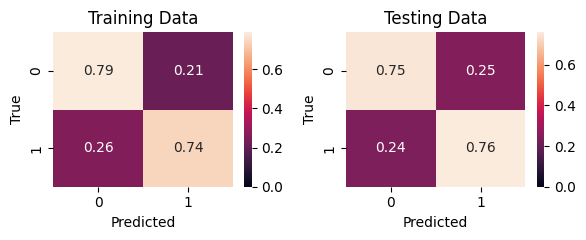

KNeighborsClassifier(n_neighbors=1)
              precision    recall  f1-score   support

           0       0.78      0.77      0.77       100
           1       0.58      0.59      0.59        54

    accuracy                           0.71       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.71      0.71       154



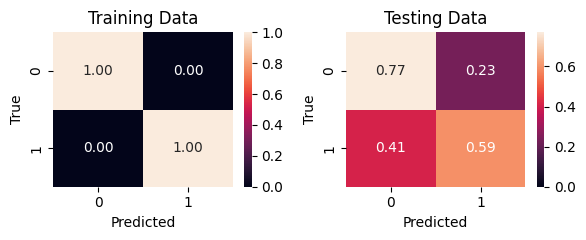

KNeighborsClassifier()
              precision    recall  f1-score   support

           0       0.81      0.64      0.72       100
           1       0.52      0.72      0.60        54

    accuracy                           0.67       154
   macro avg       0.67      0.68      0.66       154
weighted avg       0.71      0.67      0.68       154



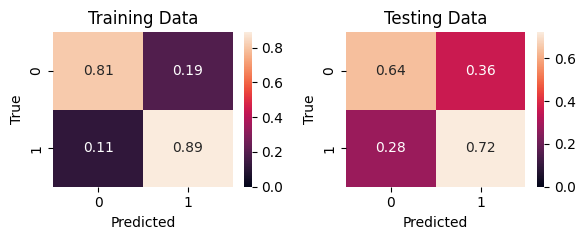

KNeighborsClassifier(n_neighbors=10)
              precision    recall  f1-score   support

           0       0.80      0.67      0.73       100
           1       0.53      0.69      0.60        54

    accuracy                           0.68       154
   macro avg       0.66      0.68      0.66       154
weighted avg       0.70      0.68      0.68       154



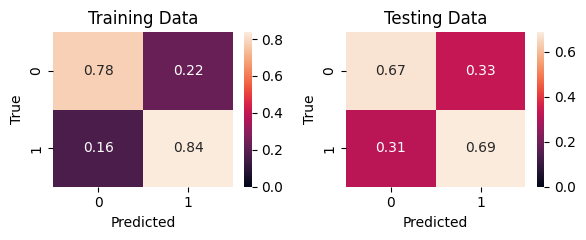

RandomForestClassifier(max_leaf_nodes=3, random_state=42)
              precision    recall  f1-score   support

           0       0.87      0.75      0.81       100
           1       0.63      0.80      0.70        54

    accuracy                           0.77       154
   macro avg       0.75      0.77      0.76       154
weighted avg       0.79      0.77      0.77       154



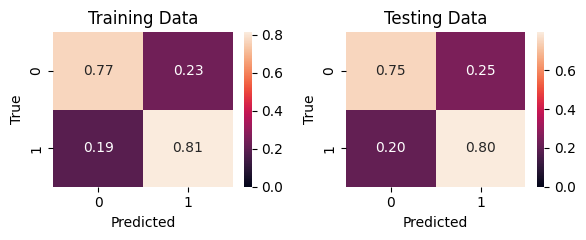

RandomForestClassifier(max_leaf_nodes=10, random_state=42)
              precision    recall  f1-score   support

           0       0.87      0.71      0.78       100
           1       0.60      0.80      0.68        54

    accuracy                           0.74       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.77      0.74      0.75       154



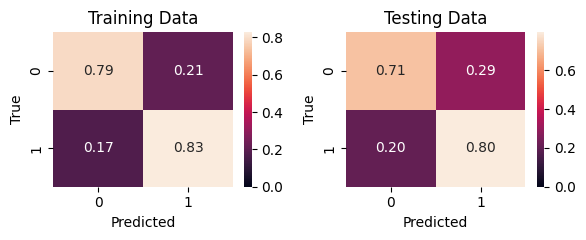

RandomForestClassifier(max_leaf_nodes=30, random_state=42)
              precision    recall  f1-score   support

           0       0.88      0.74      0.80       100
           1       0.63      0.81      0.71        54

    accuracy                           0.77       154
   macro avg       0.75      0.78      0.76       154
weighted avg       0.79      0.77      0.77       154



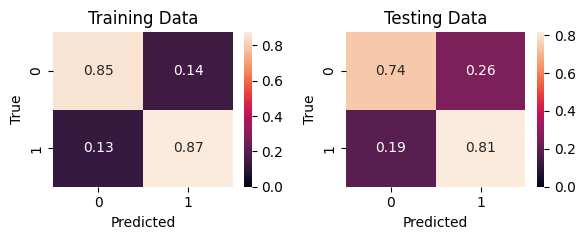

DecisionTreeClassifier(max_leaf_nodes=3, random_state=42)
              precision    recall  f1-score   support

           0       0.78      0.74      0.76       100
           1       0.56      0.61      0.58        54

    accuracy                           0.69       154
   macro avg       0.67      0.68      0.67       154
weighted avg       0.70      0.69      0.70       154



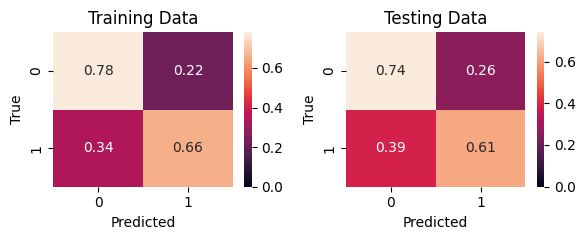

DecisionTreeClassifier(max_leaf_nodes=10, random_state=42)
              precision    recall  f1-score   support

           0       0.88      0.69      0.78       100
           1       0.59      0.83      0.69        54

    accuracy                           0.74       154
   macro avg       0.74      0.76      0.73       154
weighted avg       0.78      0.74      0.75       154



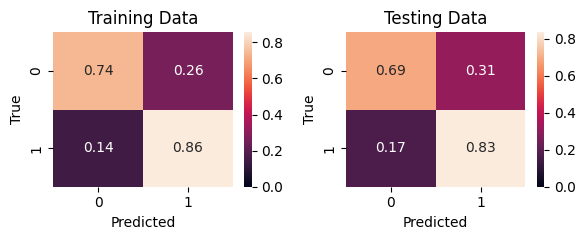

DecisionTreeClassifier(max_leaf_nodes=30, random_state=42)
              precision    recall  f1-score   support

           0       0.84      0.76      0.80       100
           1       0.62      0.72      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



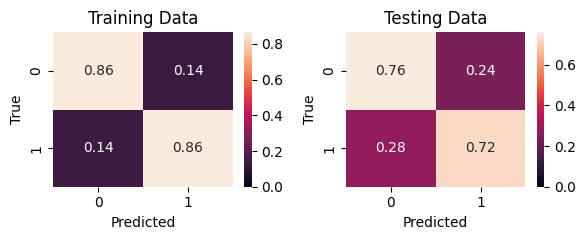

GradientBoostingClassifier(max_leaf_nodes=3, random_state=42)
              precision    recall  f1-score   support

           0       0.84      0.74      0.79       100
           1       0.61      0.74      0.67        54

    accuracy                           0.74       154
   macro avg       0.72      0.74      0.73       154
weighted avg       0.76      0.74      0.74       154



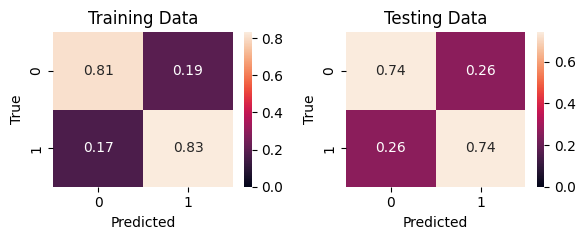

GradientBoostingClassifier(max_leaf_nodes=10, random_state=42)
              precision    recall  f1-score   support

           0       0.84      0.72      0.77       100
           1       0.59      0.74      0.66        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.73      0.73       154



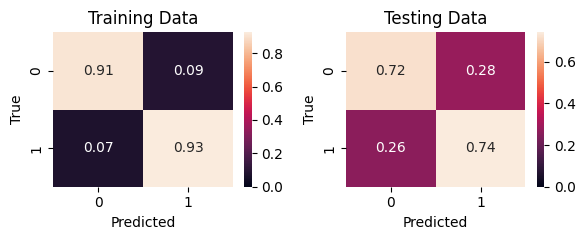

GradientBoostingClassifier(max_leaf_nodes=30, random_state=42)
              precision    recall  f1-score   support

           0       0.84      0.72      0.77       100
           1       0.59      0.74      0.66        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.73      0.73       154



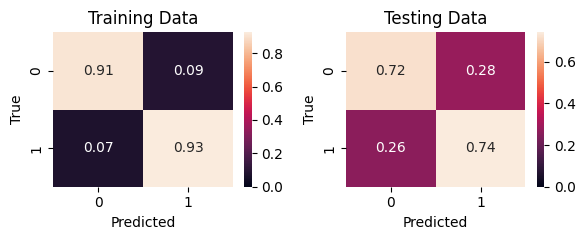

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=3, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

           0       0.89      0.75      0.82       100
           1       0.64      0.83      0.73        54

    accuracy                           0.78       154
   macro avg       0.77    

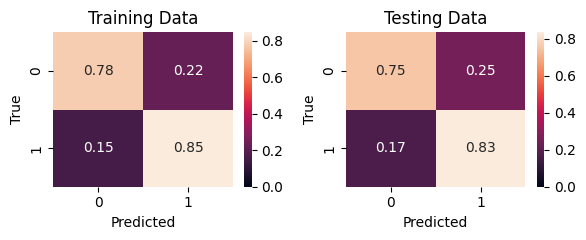

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=10, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

           0       0.83      0.75      0.79       100
           1       0.61      0.72      0.66        54

    accuracy                           0.74       154
   macro avg       0.72   

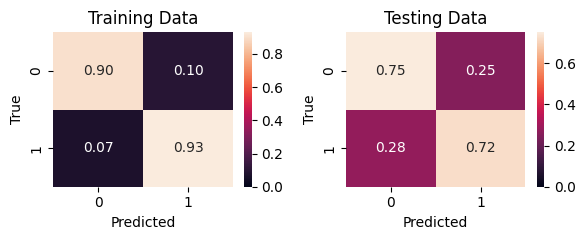

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=30, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

           0       0.83      0.76      0.79       100
           1       0.61      0.70      0.66        54

    accuracy                           0.74       154
   macro avg       0.72   

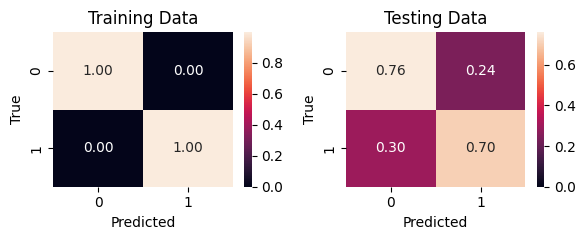

AdaBoostClassifier(learning_rate=0.1, n_estimators=100, random_state=42)
              precision    recall  f1-score   support

           0       0.88      0.69      0.78       100
           1       0.59      0.83      0.69        54

    accuracy                           0.74       154
   macro avg       0.74      0.76      0.73       154
weighted avg       0.78      0.74      0.75       154



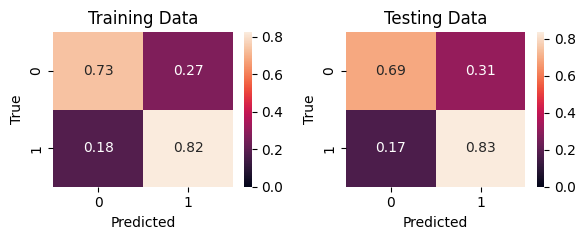

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

for m in models:
    # wrap this model in the pipeline
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(k_neighbors=10, random_state=42)),
        ('clf',    m),
    ])
    pipe.fit(X_train, y_train)          # scales + SMOTEs internally, then fits m

    print(m)
    y_train_pred = pipe.predict(X_train)   # real rows, scaled, not SMOTEd
    y_test_pred  = pipe.predict(X_test)

    print(classification_report(y_test, y_test_pred))

    conf_matrix_train = confusion_matrix(y_train, y_train_pred).astype(float)
    conf_matrix_test  = confusion_matrix(y_test,  y_test_pred).astype(float)

    for i in range(conf_matrix_train.shape[0]):
        conf_matrix_train[i,:] = conf_matrix_train[i,:] / conf_matrix_train[i,:].sum()
        conf_matrix_test[i,:]  = conf_matrix_test[i,:] / conf_matrix_test[i,:].sum()
    # end

    # Create subplots for side-by-side visualization
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2.5))

    # Plot confusion matrix for training data
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='.2f', ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")

    # Plot confusion matrix for test data
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='.2f', ax=axes[1])
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")

    # Show the plots
    plt.tight_layout()
    plt.show()
# end

This uses X_train_res

In [17]:
'''from sklearn.metrics import classification_report, confusion_matrix

for m in models:
    m.fit(X_train_res, y_train_res)
    y_train_pred = m.predict(X_train_res)
    y_test_pred = m.predict(X_test)

    print(m)
    print(classification_report(y_test, y_test_pred))

    # Compute confusion matrices
    conf_matrix_train = confusion_matrix(y_train_res, y_train_pred)
    conf_matrix_test = confusion_matrix(y_test, y_test_pred)

    conf_matrix_train = conf_matrix_train.astype(float)
    conf_matrix_test  = conf_matrix_test.astype(float)
    for i in range(conf_matrix_train.shape[0]):
        conf_matrix_train[i,:] = conf_matrix_train[i,:] / conf_matrix_train[i,:].sum()
        conf_matrix_test[i,:]  = conf_matrix_test[i,:] / conf_matrix_test[i,:].sum()
    # end

    # Create subplots for side-by-side visualization
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2.5))

    # Plot confusion matrix for training data
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='.2f', ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")

    # Plot confusion matrix for test data
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='.2f', ax=axes[1])
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")

    # Show the plots
    plt.tight_layout()
    plt.show()
# end'''


'from sklearn.metrics import classification_report, confusion_matrix\n\nfor m in models:\n    m.fit(X_train_res, y_train_res)\n    y_train_pred = m.predict(X_train_res)\n    y_test_pred = m.predict(X_test)\n\n    print(m)\n    print(classification_report(y_test, y_test_pred))\n\n    # Compute confusion matrices\n    conf_matrix_train = confusion_matrix(y_train_res, y_train_pred)\n    conf_matrix_test = confusion_matrix(y_test, y_test_pred)\n\n    conf_matrix_train = conf_matrix_train.astype(float)\n    conf_matrix_test  = conf_matrix_test.astype(float)\n    for i in range(conf_matrix_train.shape[0]):\n        conf_matrix_train[i,:] = conf_matrix_train[i,:] / conf_matrix_train[i,:].sum()\n        conf_matrix_test[i,:]  = conf_matrix_test[i,:] / conf_matrix_test[i,:].sum()\n    # end\n\n    # Create subplots for side-by-side visualization\n    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2.5))\n\n    # Plot confusion matrix for training data\n    sns.heatmap(conf_matrix_train, 

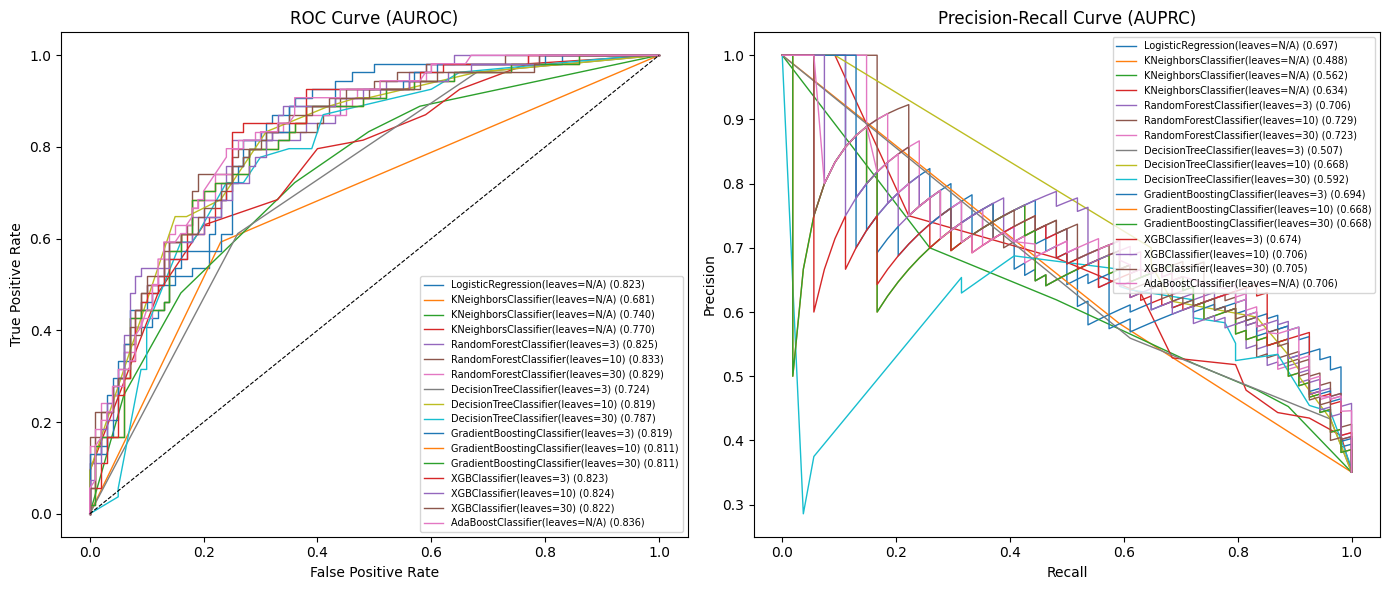

In [27]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, roc_auc_score, matthews_corrcoef
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Create a list to store pipelines for consistent evaluation
pipelines = []
for m in models:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(k_neighbors=10, random_state=42)),
        ('clf',    m),
    ])
    pipe.fit(X_train, y_train) # Fit each pipeline on the original X_train, y_train
    model_name = f"{m.__class__.__name__}(leaves={getattr(m, 'max_leaf_nodes', getattr(m, 'max_leaves', 'N/A'))})"
    pipelines.append({'pipe': pipe, 'name': model_name})

for pipeline_result in pipelines:
    pipe = pipeline_result['pipe']
    name = pipeline_result['name']

    # Ensure the classifier in the pipeline has predict_proba
    if hasattr(pipe.named_steps['clf'], 'predict_proba'):
        y_prob = pipe.predict_proba(X_test)[:, 1]
    else:
        # Handle models without predict_proba if necessary, e.g., default to 0.5 or raise error
        y_prob = [0.5] * len(y_test) # Placeholder

    # ROC curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auroc = roc_auc_score(y_test, y_prob)
    axes[0].plot(fpr, tpr, label=f"{name} ({auroc:.3f})", linewidth=1)

    # PR curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    axes[1].plot(recall_vals, precision_vals, label=f"{name} ({ap:.3f})", linewidth=1)

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8)
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            title='ROC Curve (AUROC)')
axes[0].legend(fontsize=7, loc='lower right')

axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve (AUPRC)')
axes[1].legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

In [19]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score

model_to_evaluate = models[0] # Currently Decision Tree Max Node 3, Change this to select a different model

y_score = model_to_evaluate.predict_proba(X_test)[:, 1]
auprc = average_precision_score(y_test, y_score)
auroc = roc_auc_score(y_test, y_score)
print("AUPRC:", auprc)
print("AUROC:", auroc)

AUPRC: 0.35294117647058826
AUROC: 0.505


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(



Model: LogisticRegression(leaves=N/A)
              precision    recall  f1-score   support

           0       0.85      0.75      0.80       100
           1       0.62      0.76      0.68        54

    accuracy                           0.75       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.75      0.76       154



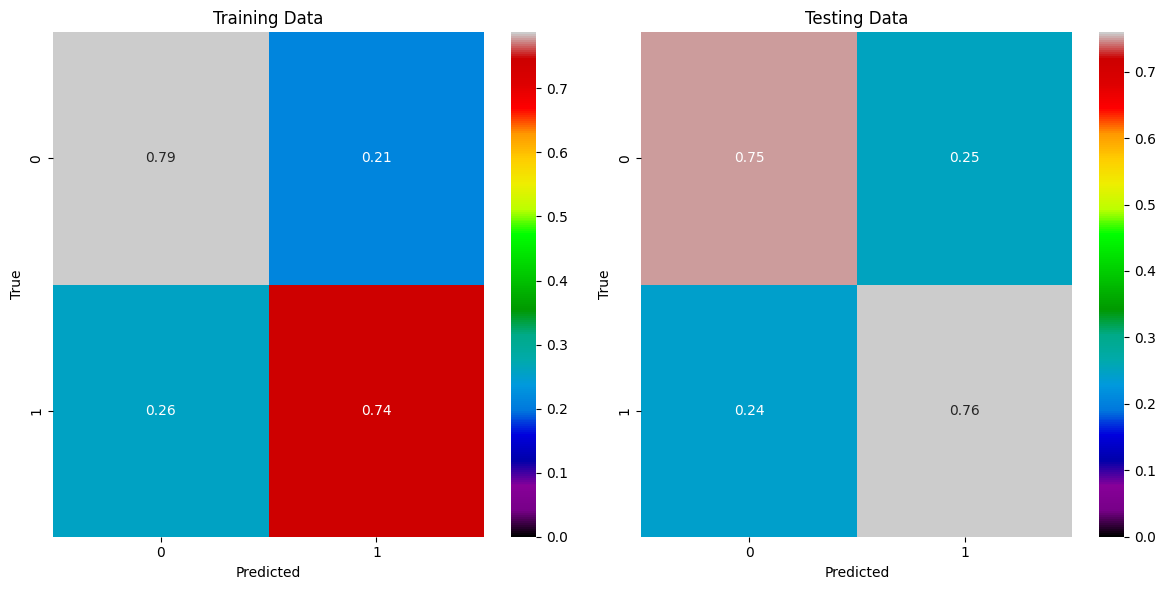


Model: KNeighborsClassifier(leaves=N/A)
              precision    recall  f1-score   support

           0       0.78      0.77      0.77       100
           1       0.58      0.59      0.59        54

    accuracy                           0.71       154
   macro avg       0.68      0.68      0.68       154
weighted avg       0.71      0.71      0.71       154



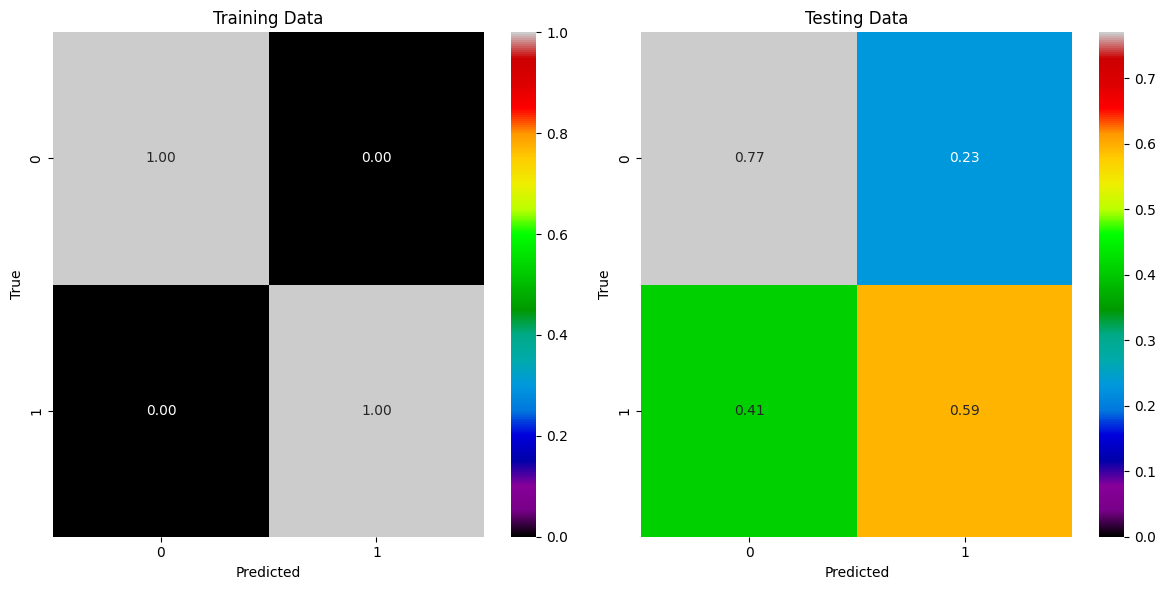


Model: KNeighborsClassifier(leaves=N/A)
              precision    recall  f1-score   support

           0       0.81      0.64      0.72       100
           1       0.52      0.72      0.60        54

    accuracy                           0.67       154
   macro avg       0.67      0.68      0.66       154
weighted avg       0.71      0.67      0.68       154



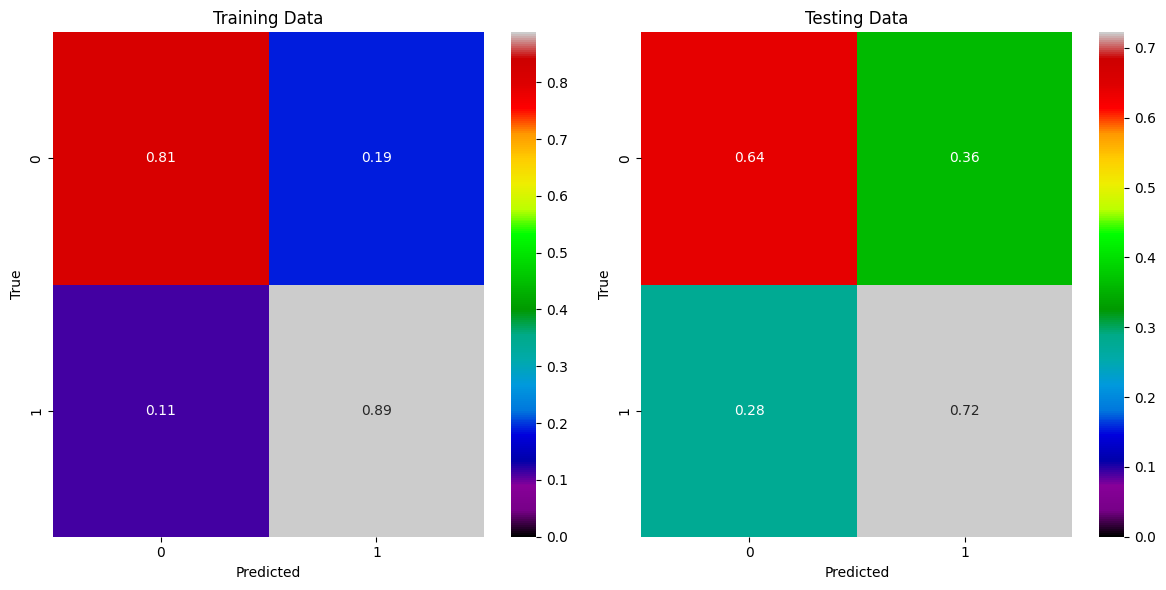


Model: KNeighborsClassifier(leaves=N/A)
              precision    recall  f1-score   support

           0       0.80      0.67      0.73       100
           1       0.53      0.69      0.60        54

    accuracy                           0.68       154
   macro avg       0.66      0.68      0.66       154
weighted avg       0.70      0.68      0.68       154



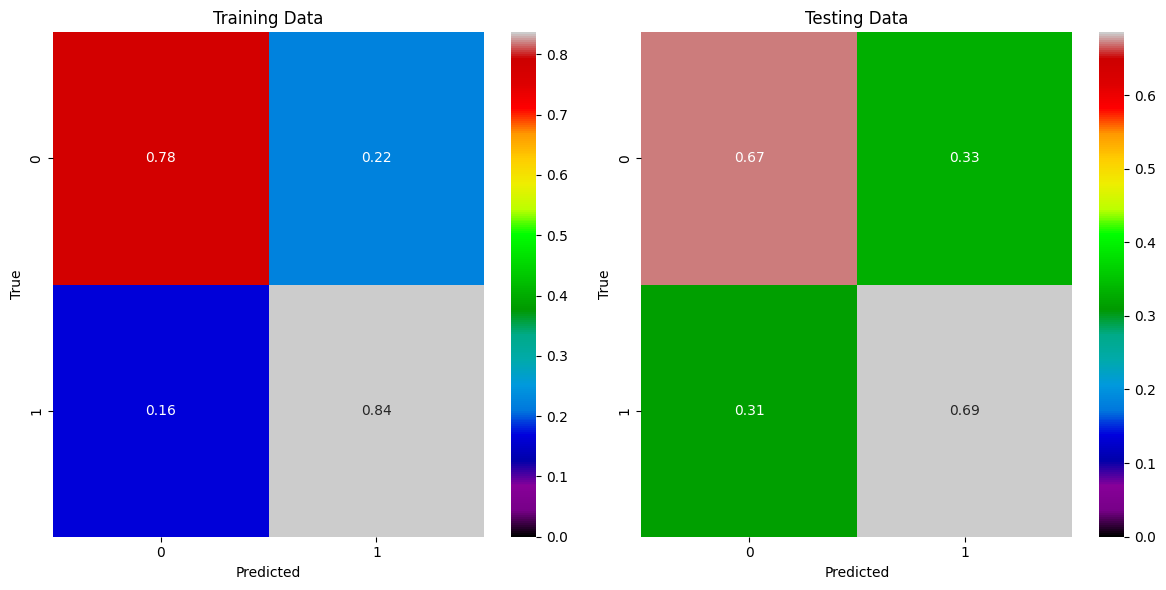


Model: RandomForestClassifier(leaves=3)
              precision    recall  f1-score   support

           0       0.87      0.75      0.81       100
           1       0.63      0.80      0.70        54

    accuracy                           0.77       154
   macro avg       0.75      0.77      0.76       154
weighted avg       0.79      0.77      0.77       154



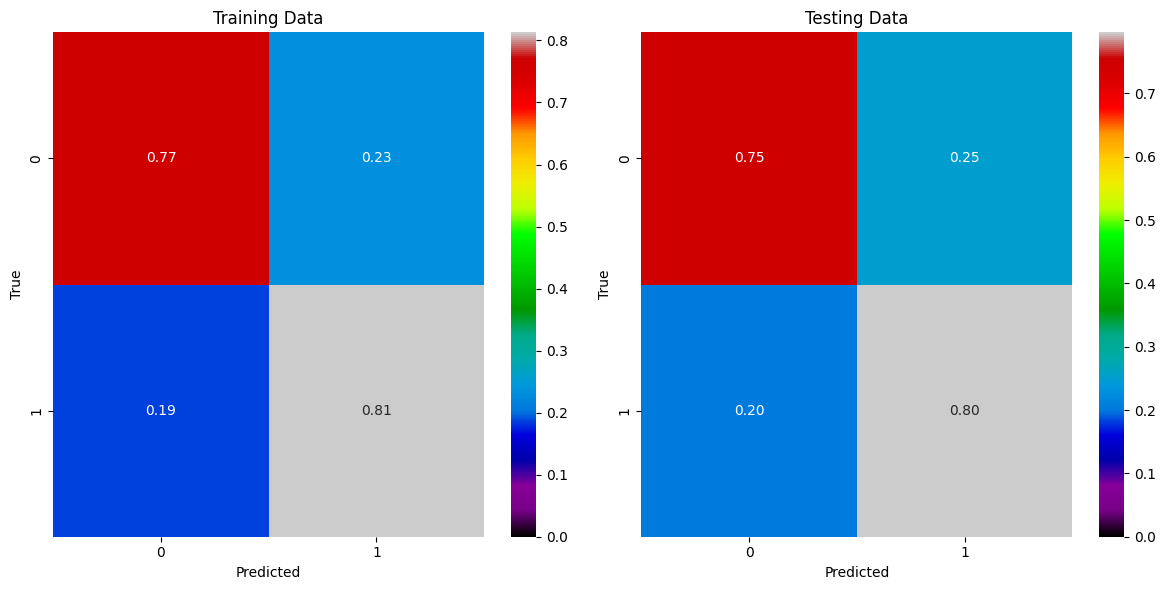


Model: RandomForestClassifier(leaves=10)
              precision    recall  f1-score   support

           0       0.87      0.71      0.78       100
           1       0.60      0.80      0.68        54

    accuracy                           0.74       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.77      0.74      0.75       154



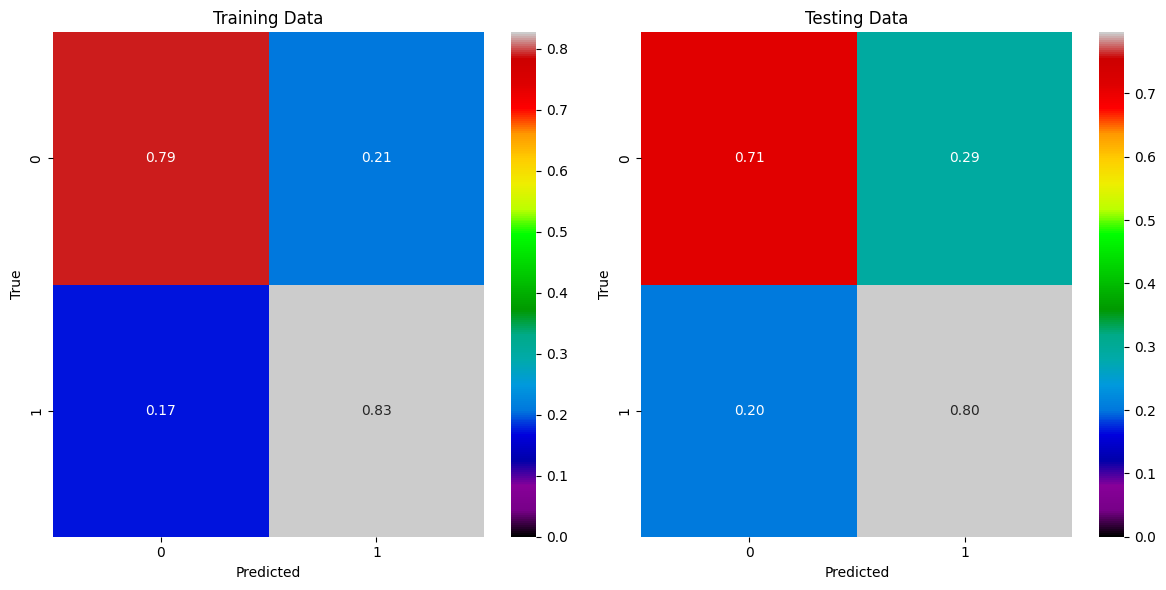


Model: RandomForestClassifier(leaves=30)
              precision    recall  f1-score   support

           0       0.88      0.74      0.80       100
           1       0.63      0.81      0.71        54

    accuracy                           0.77       154
   macro avg       0.75      0.78      0.76       154
weighted avg       0.79      0.77      0.77       154



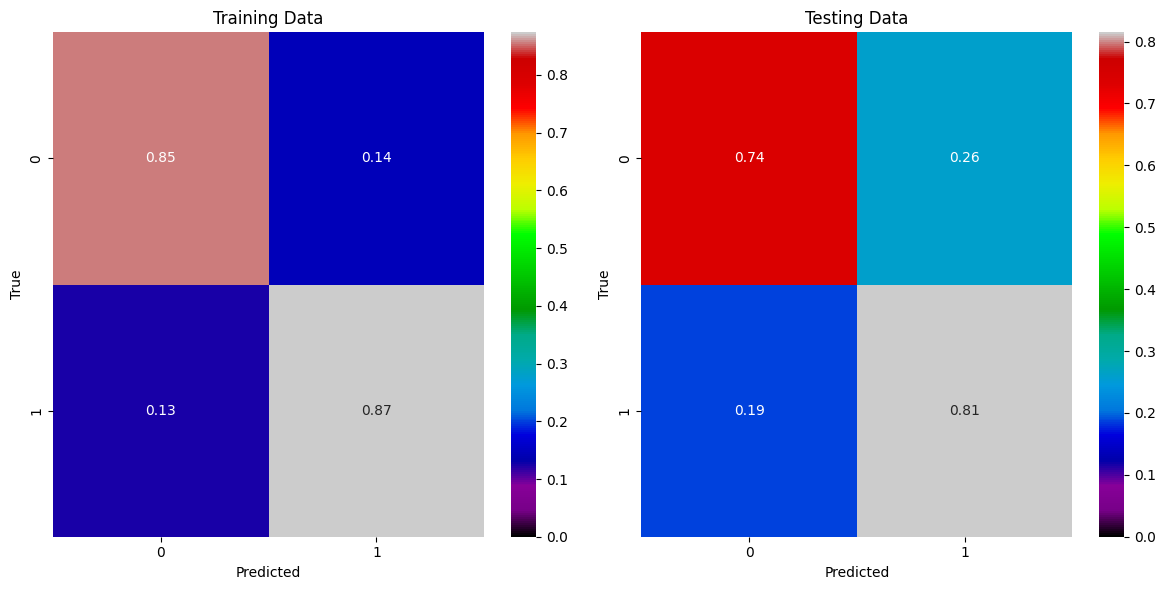


Model: DecisionTreeClassifier(leaves=3)
              precision    recall  f1-score   support

           0       0.78      0.74      0.76       100
           1       0.56      0.61      0.58        54

    accuracy                           0.69       154
   macro avg       0.67      0.68      0.67       154
weighted avg       0.70      0.69      0.70       154



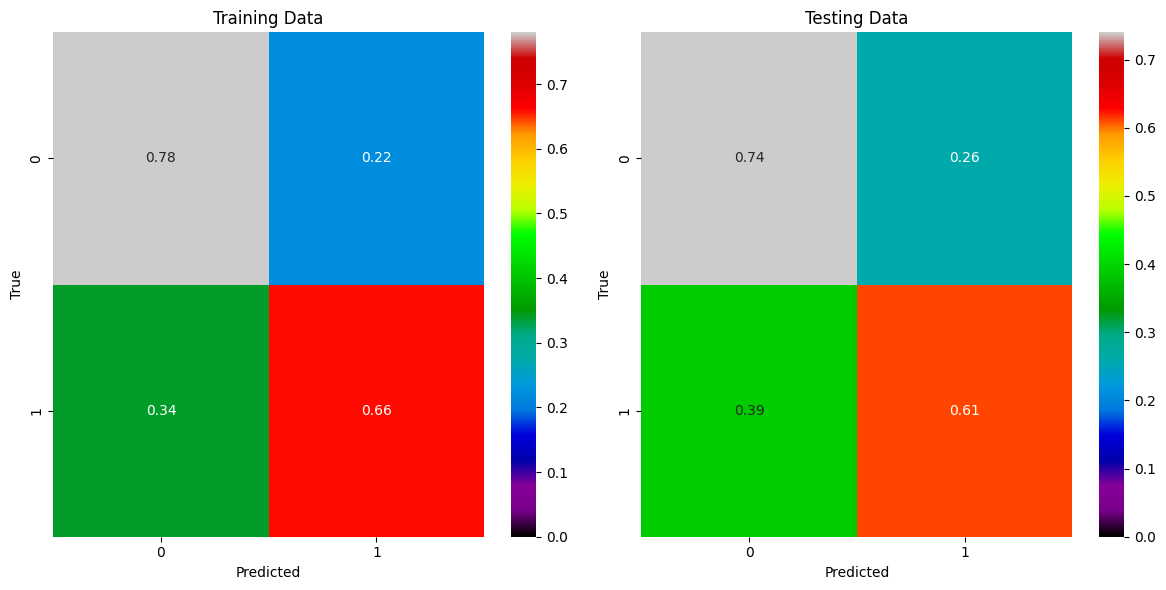


Model: DecisionTreeClassifier(leaves=10)
              precision    recall  f1-score   support

           0       0.88      0.69      0.78       100
           1       0.59      0.83      0.69        54

    accuracy                           0.74       154
   macro avg       0.74      0.76      0.73       154
weighted avg       0.78      0.74      0.75       154



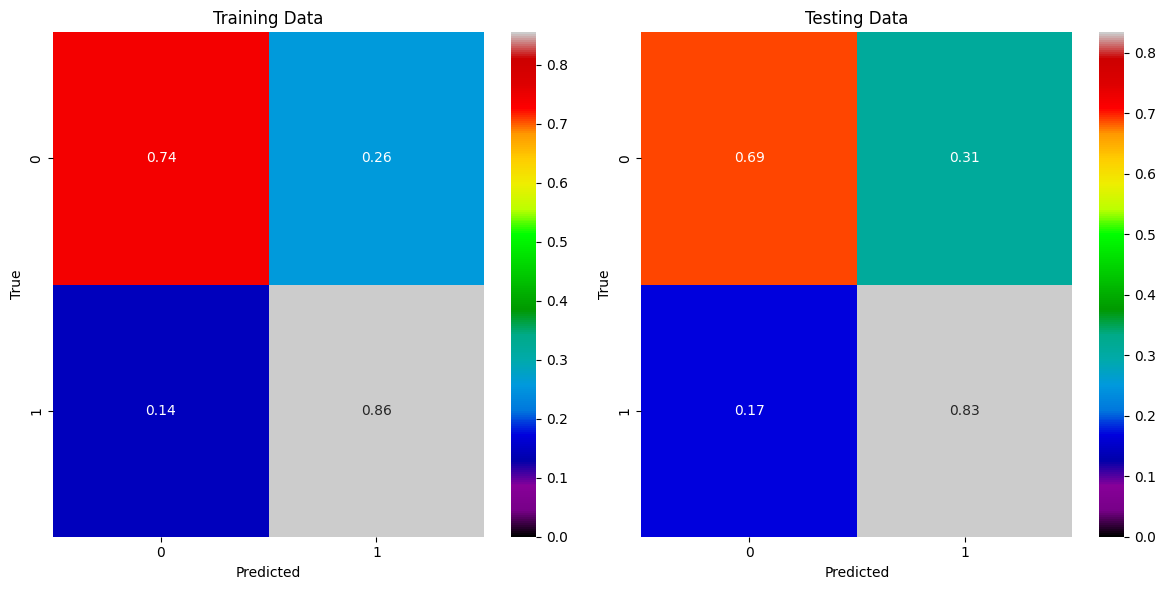


Model: DecisionTreeClassifier(leaves=30)
              precision    recall  f1-score   support

           0       0.84      0.76      0.80       100
           1       0.62      0.72      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



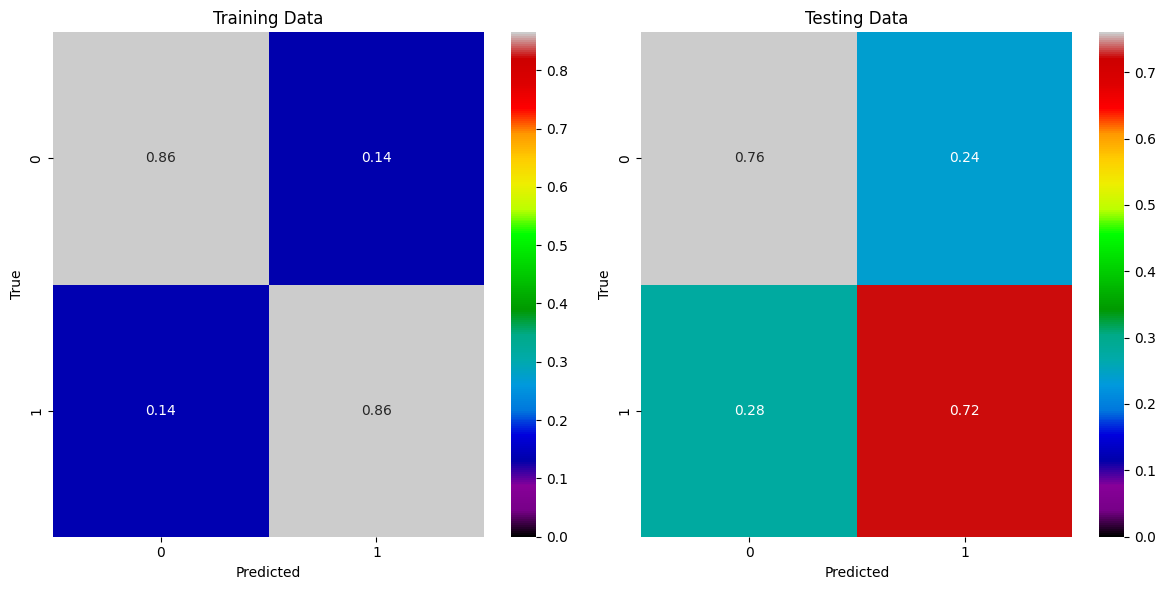


Model: GradientBoostingClassifier(leaves=3)
              precision    recall  f1-score   support

           0       0.84      0.74      0.79       100
           1       0.61      0.74      0.67        54

    accuracy                           0.74       154
   macro avg       0.72      0.74      0.73       154
weighted avg       0.76      0.74      0.74       154



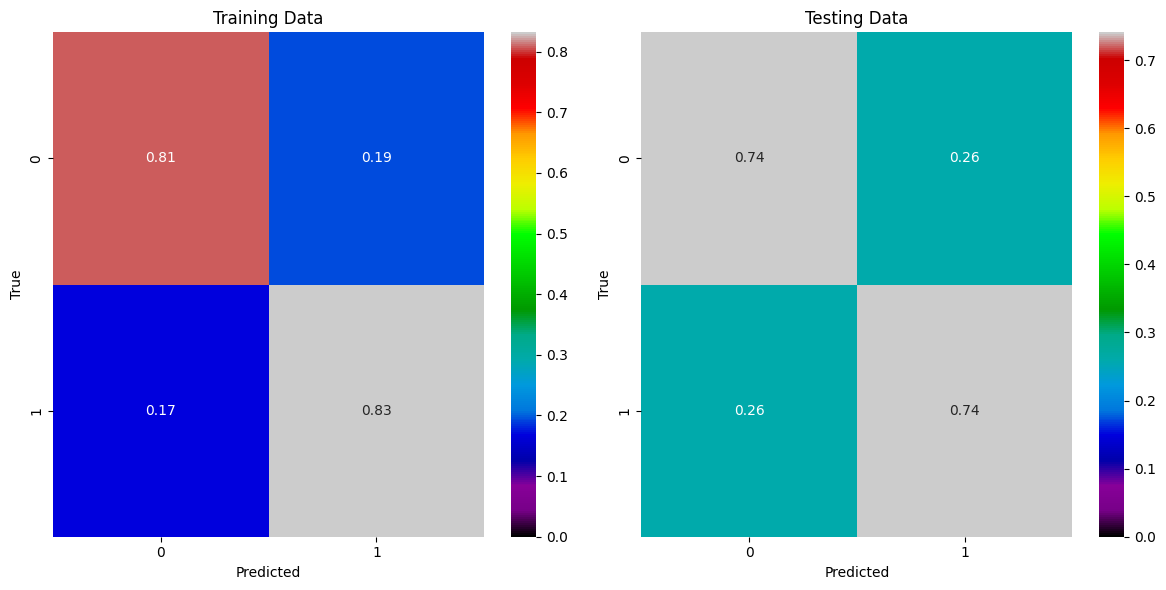


Model: GradientBoostingClassifier(leaves=10)
              precision    recall  f1-score   support

           0       0.84      0.72      0.77       100
           1       0.59      0.74      0.66        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.73      0.73       154



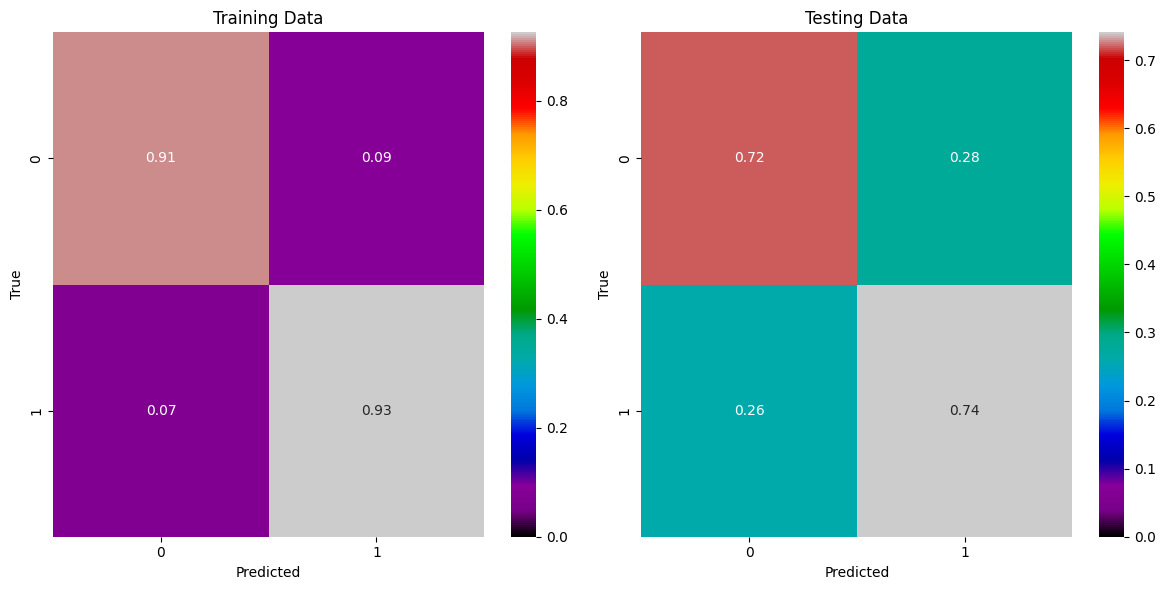


Model: GradientBoostingClassifier(leaves=30)
              precision    recall  f1-score   support

           0       0.84      0.72      0.77       100
           1       0.59      0.74      0.66        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.71       154
weighted avg       0.75      0.73      0.73       154



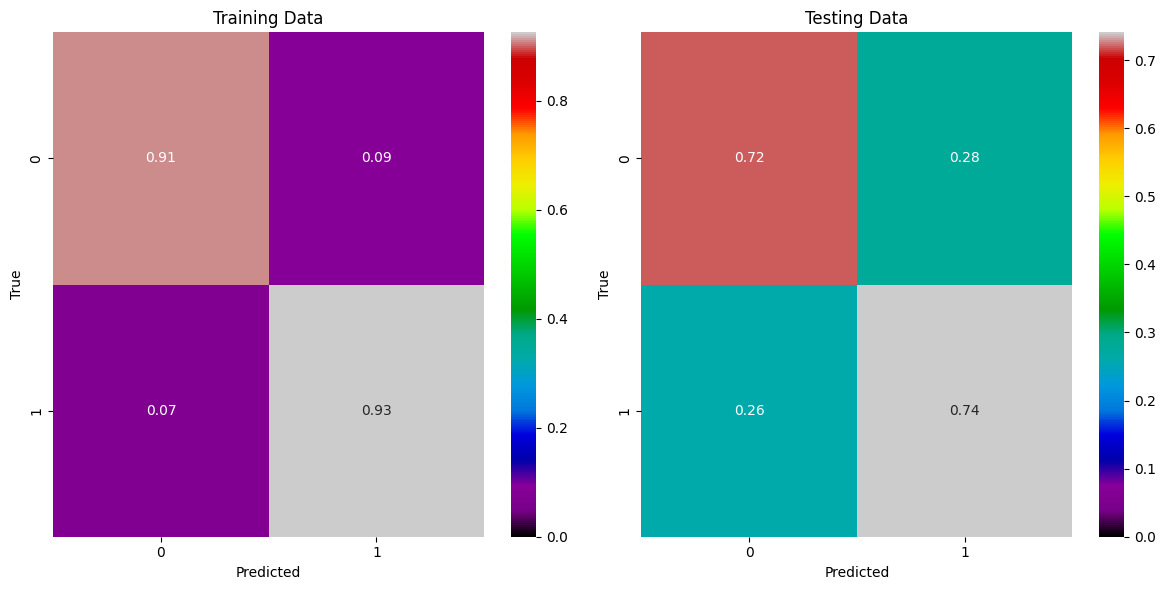


Model: XGBClassifier(leaves=3)
              precision    recall  f1-score   support

           0       0.89      0.75      0.82       100
           1       0.64      0.83      0.73        54

    accuracy                           0.78       154
   macro avg       0.77      0.79      0.77       154
weighted avg       0.81      0.78      0.78       154



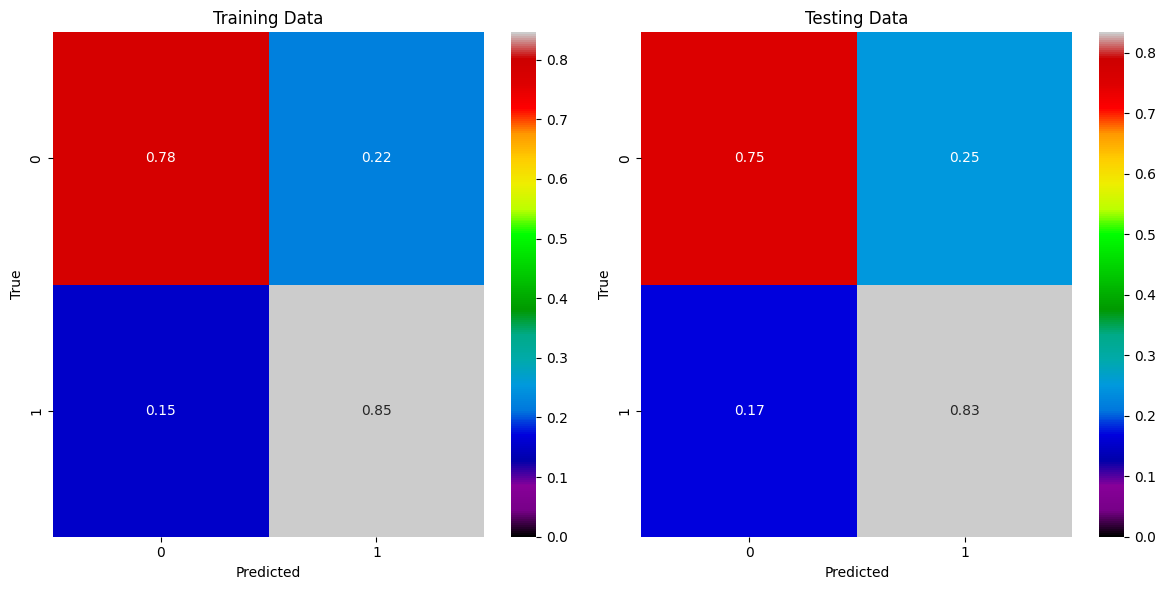


Model: XGBClassifier(leaves=10)
              precision    recall  f1-score   support

           0       0.83      0.75      0.79       100
           1       0.61      0.72      0.66        54

    accuracy                           0.74       154
   macro avg       0.72      0.74      0.73       154
weighted avg       0.75      0.74      0.74       154



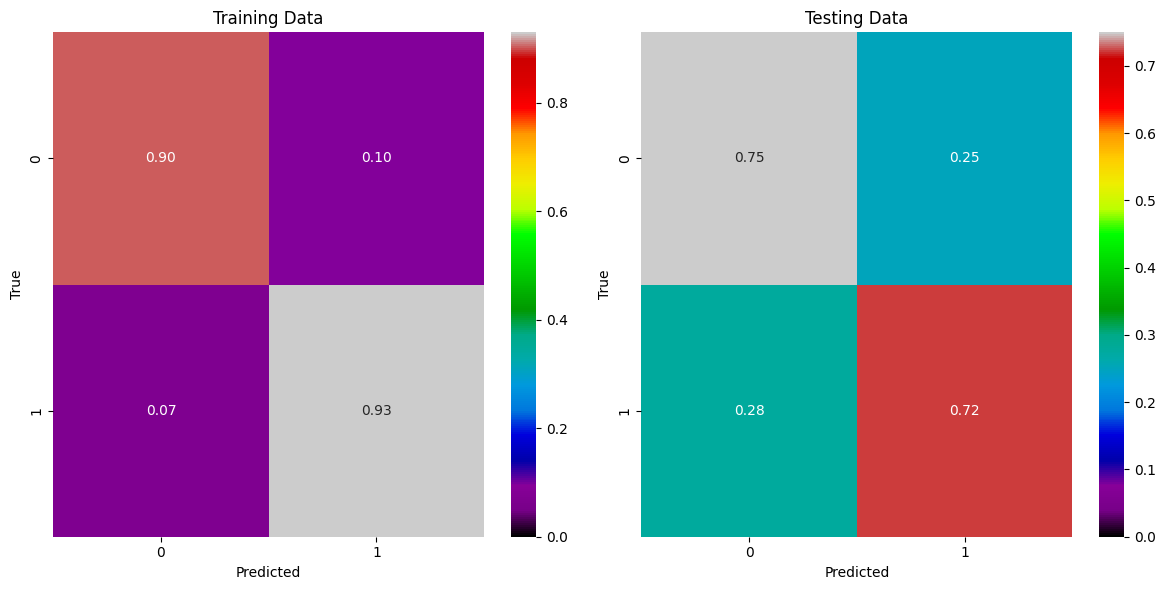


Model: XGBClassifier(leaves=30)
              precision    recall  f1-score   support

           0       0.83      0.76      0.79       100
           1       0.61      0.70      0.66        54

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0.75      0.74      0.74       154



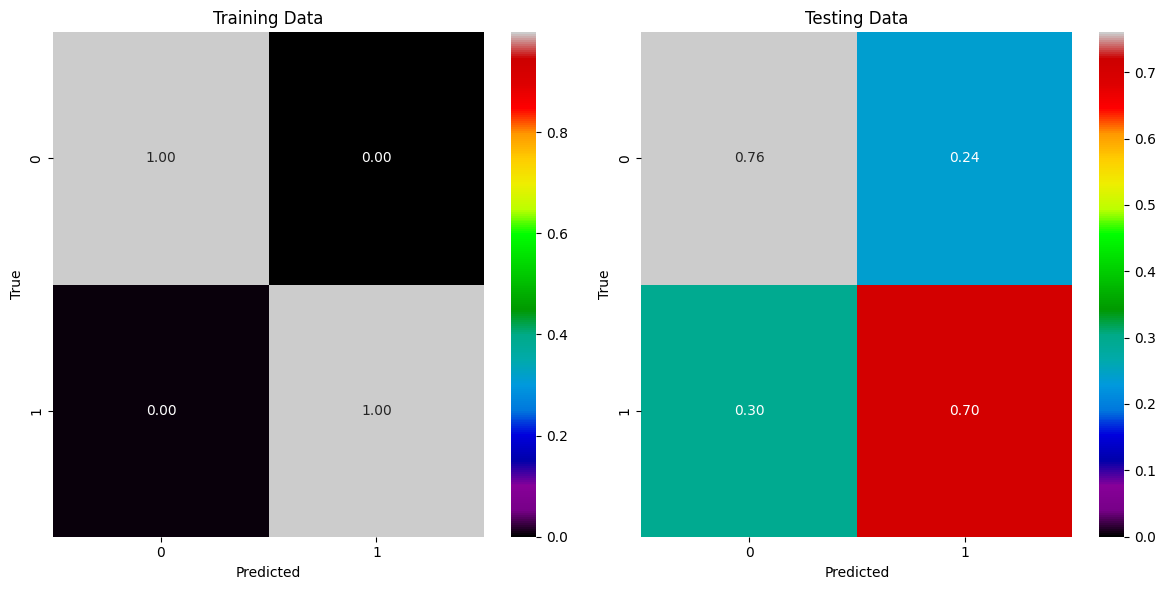


Model: AdaBoostClassifier(leaves=N/A)
              precision    recall  f1-score   support

           0       0.88      0.69      0.78       100
           1       0.59      0.83      0.69        54

    accuracy                           0.74       154
   macro avg       0.74      0.76      0.73       154
weighted avg       0.78      0.74      0.75       154



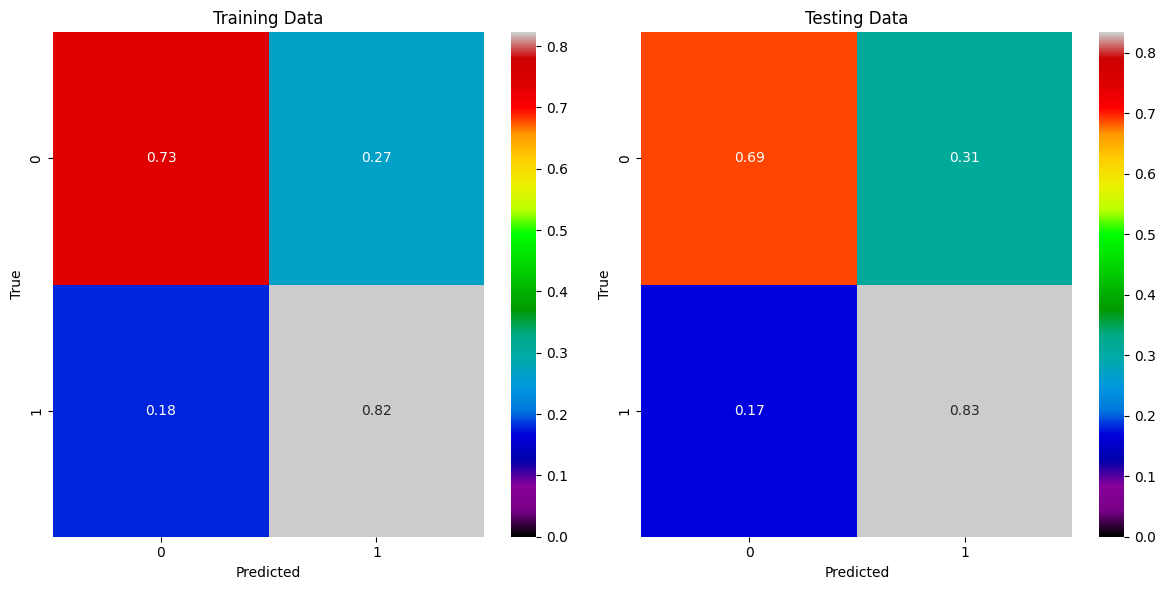


=== Model Comparison (sorted by AUPRC) ===
                                Model    AUPRC    AUROC      MCC       F1
    RandomForestClassifier(leaves=10) 0.728827 0.832778 0.484204 0.682540
    RandomForestClassifier(leaves=30) 0.722749 0.828889 0.531687 0.709677
             XGBClassifier(leaves=10) 0.706364 0.823519 0.457227 0.661017
       AdaBoostClassifier(leaves=N/A) 0.705732 0.835741 0.499484 0.692308
     RandomForestClassifier(leaves=3) 0.705587 0.825370 0.524954 0.704918
             XGBClassifier(leaves=30) 0.704652 0.822222 0.451178 0.655172
       LogisticRegression(leaves=N/A) 0.696726 0.822593 0.491046 0.683333
 GradientBoostingClassifier(leaves=3) 0.694132 0.818889 0.463548 0.666667
              XGBClassifier(leaves=3) 0.674041 0.823333 0.559017 0.725806
    DecisionTreeClassifier(leaves=10) 0.668183 0.818796 0.499484 0.692308
GradientBoostingClassifier(leaves=10) 0.667828 0.810741 0.442741 0.655738
GradientBoostingClassifier(leaves=30) 0.667828 0.810741 0.442741 0.6

In [20]:
from sklearn.metrics import classification_report, confusion_matrix, average_precision_score, roc_auc_score, matthews_corrcoef, f1_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

results = []

for i, m in enumerate(models):
    # Wrap the model in a pipeline with StandardScaler and SMOTE
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(k_neighbors=10, random_state=42)),
        ('clf', m),
    ])

    pipe.fit(X_train, y_train) # Fit the pipeline on original X_train, y_train

    # Make predictions using the pipeline
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    # Calculate y_prob for the current model
    # Ensure the classifier in the pipeline has predict_proba
    if hasattr(pipe.named_steps['clf'], 'predict_proba'):
        y_prob = pipe.predict_proba(X_test)[:, 1]
    else:
        # Handle models without predict_proba if necessary, e.g., default to 0.5 or raise error
        y_prob = [0.5] * len(y_test) # Placeholder, adjust as needed

    auprc = average_precision_score(y_test, y_prob)
    auroc = roc_auc_score(y_test, y_prob)
    mcc   = matthews_corrcoef(y_test, y_test_pred)
    f1    = f1_score(y_test, y_test_pred)
    name  = f"{m.__class__.__name__}(leaves={getattr(m, 'max_leaf_nodes', getattr(m, 'max_leaves', 'N/A'))})"

    results.append({
        'Model': name,
        'AUPRC': auprc,
        'AUROC': auroc,
        'MCC':   mcc,
        'F1':    f1,
    })

    print(f"\n{'='*60}")
    print(f"Model: {name}")
    print(classification_report(y_test, y_test_pred))

    # Compute confusion matrices
    conf_matrix_train = confusion_matrix(y_train, y_train_pred)
    conf_matrix_test = confusion_matrix(y_test, y_test_pred)

    conf_matrix_train = conf_matrix_train.astype(float)
    conf_matrix_test  = conf_matrix_test.astype(float)
    for row_idx in range(conf_matrix_train.shape[0]):
        if conf_matrix_train[row_idx,:].sum() > 0:
            conf_matrix_train[row_idx,:] = conf_matrix_train[row_idx,:] / conf_matrix_train[row_idx,:].sum()
        if conf_matrix_test[row_idx,:].sum() > 0:
            conf_matrix_test[row_idx,:]  = conf_matrix_test[row_idx,:] / conf_matrix_test[row_idx,:].sum()

    # Create subplots for side-by-side visualization
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

    # Plot confusion matrix for training data
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='.2f', ax=axes[0], cmap='nipy_spectral')
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")

    # Plot confusion matrix for test data
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='.2f', ax=axes[1], cmap='nipy_spectral')
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")

    plt.tight_layout()
    plt.show()

# --- Model comparison table ───────────────────────────────────────────────────
results_df = pd.DataFrame(results).sort_values('AUPRC', ascending=False).reset_index(drop=True)
print("\n=== Model Comparison (sorted by AUPRC) ===")
print(results_df.to_string(index=False))


In [21]:
! pip install SHAP

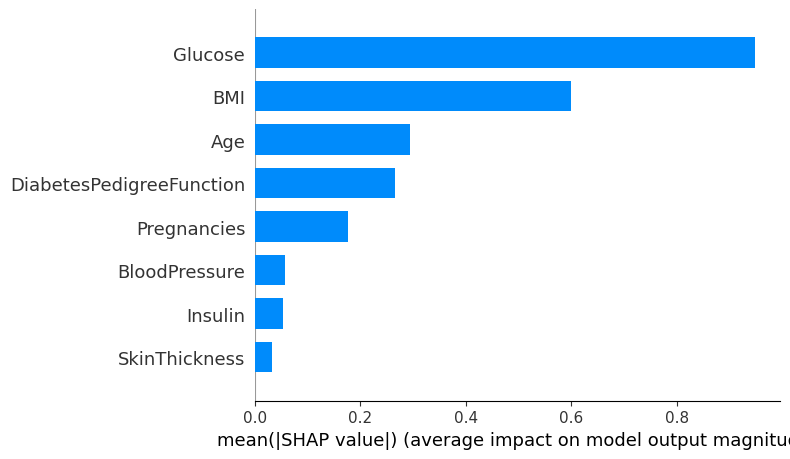

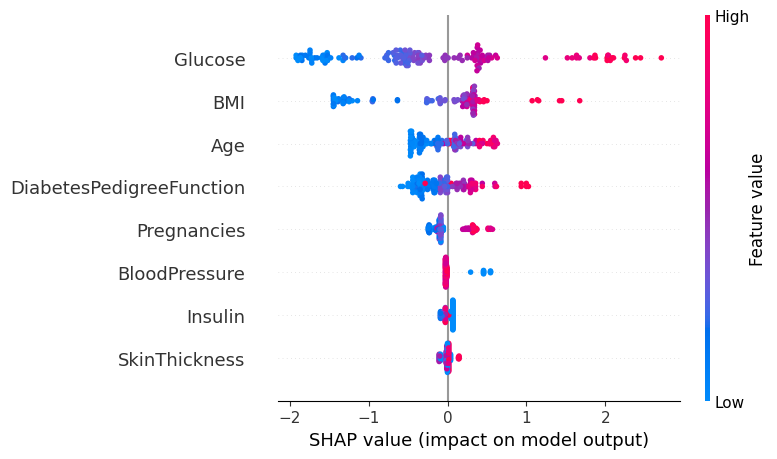

In [22]:
import shap

# Choose one of the trained models for explanation (e.g., the first XGBoost model)
# model_to_explain = models[9] # This is xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3)
# Or, if you want to use the best performing model from your MLflow run, you would select it here.

# Let's refit the chosen model just to be safe, as the `models` list might not contain fitted versions
model_to_explain = models[13] # Changed to a tree-based model, e.g., xgb.XGBClassifier
model_to_explain.fit(X_train, y_train)

# Create a SHAP explainer
explainer = shap.TreeExplainer(model_to_explain)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test)

# Plot the SHAP summary plot (Feature Importance)
shap.summary_plot(shap_values, X_test, plot_type="bar")

# You can also get a more detailed summary plot
shap.summary_plot(shap_values, X_test)

# Deep Learning

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

dropout_rate = 0.1

n_classes = np.unique(y).shape[0]

# Create model
model = Sequential([
    Input(shape=X.shape[1:]),

    Dense(20, activation='relu'),
    BatchNormalization(),
    Dropout(dropout_rate),

    #Dense(20, activation='relu'),
    #BatchNormalization(),
    #Dropout(dropout_rate),

    #Dense(20, activation='relu'),
    #BatchNormalization(),
    #Dropout(dropout_rate),

    Dense(20, activation='relu'),

    Dense(n_classes, activation='softmax'),
])

# Define the optimizer with a custom learning rate
optimizer = Adam(learning_rate=0.005)

# Compile model
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=100,          # Stop after 5 epochs without improvement
    restore_best_weights=True  # Restore the best weights after stopping
)

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           180 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 20)             │            80 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │            42 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722 (2.82 KB)

 Trainable params: 682 (2.66 KB)

 Non-trainable params: 40 (160.00 B)

Training KERAS MODEL

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. carve a validation set OUT OF X_train (not X_test)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=42)

# 2. scale: fit on training part only
scaler = StandardScaler()
X_tr_s  = scaler.fit_transform(X_tr)
X_val_s = scaler.transform(X_val)     # transform only
X_test_s = scaler.transform(X_test)   # for the final evaluation later

# 3. SMOTE the scaled training part only
X_tr_res, y_tr_res = SMOTE(k_neighbors=10, random_state=42).fit_resample(X_tr_s, y_tr)

# 4. train on SMOTEd scaled data; validate on REAL scaled val set
history = model.fit(
    X_tr_res, y_tr_res,
    validation_data=(X_val_s, y_val),   # real, held-out — NOT X_test
    epochs=100, batch_size=256,
    callbacks=[early_stopping], verbose=1,
)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 412ms/step - accuracy: 0.5953 - loss: 0.9533 - val_accuracy: 0.6504 - val_loss: 3.4208
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 206ms/step - accuracy: 0.6125 - loss: 0.7766 - val_accuracy: 0.6504 - val_loss: 2.4062
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 204ms/step - accuracy: 0.6828 - loss: 0.6059 - val_accuracy: 0.6504 - val_loss: 1.7430
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 252ms/step - accuracy: 0.7000 - loss: 0.5744 - val_accuracy: 0.6504 - val_loss: 1.4154
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 254ms/step - accuracy: 0.7328 - loss: 0.5484 - val_accuracy: 0.6504 - val_loss: 1.3654
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 304ms/step - accuracy: 0.7109 - loss: 0.5572 - val_accuracy: 0.6504 - val_loss: 1.4393
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step - accuracy: 0.7422 - loss: 0.5136 - val_accuracy: 0.6504 - val_loss: 1.5680
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.7625 - loss: 0.5049 - val_accuracy: 0.6504 - v

In [29]:
'''# Train model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=256,
    shuffle=True,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping],
    verbose=1,
)'''

'# Train model\nhistory = model.fit(\n    X_train, y_train,\n    epochs=100,\n    batch_size=256,\n    shuffle=True,\n    validation_data=(X_test, y_test),\n    callbacks=[early_stopping],\n    verbose=1,\n)'

PLOTTING CONFUSION MATRIX and CLASSIFICATION REPORT FOR KERAS MODEL

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


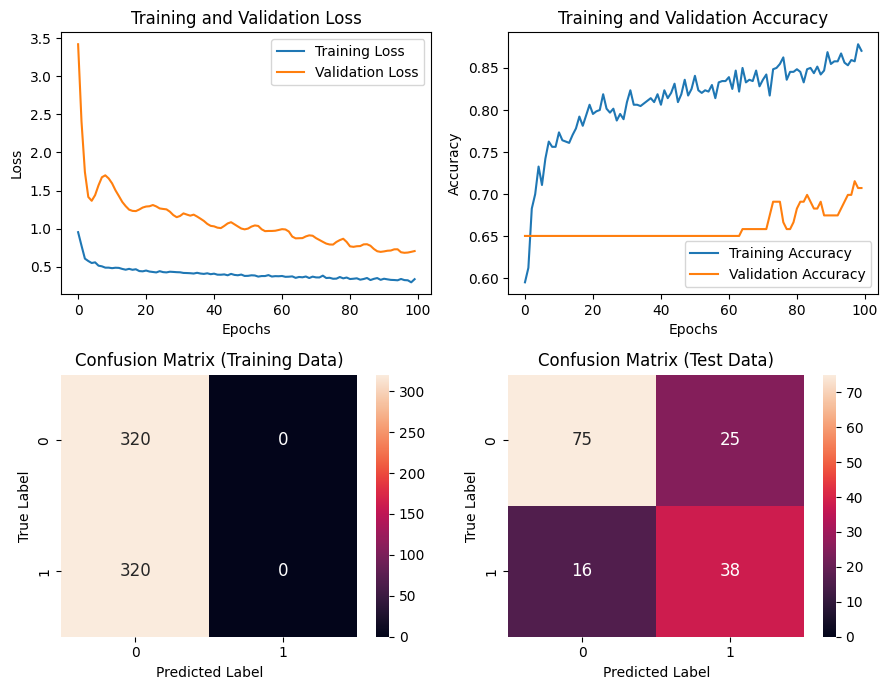

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



In [30]:
from sklearn.metrics import classification_report, confusion_matrix

# Predictions
y_train_pred = model.predict(X_tr_res).argmax(axis=1)
y_test_pred  = model.predict(X_test).argmax(axis=1)

# Confusion matrices
cm_train = confusion_matrix(y_tr_res, y_train_pred)
cm_test  = confusion_matrix(y_test, y_test_pred)

# 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(9, 7))

# Top-left: Training and Validation Loss
axes[0, 0].plot(history.history['loss'], label='Training Loss')
axes[0, 0].plot(history.history['val_loss'], label='Validation Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].set_xlabel('Epochs')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()

# Top-right: Training and Validation Accuracy
axes[0, 1].plot(history.history['accuracy'], label='Training Accuracy')
axes[0, 1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].set_xlabel('Epochs')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()

# Bottom-left: Confusion Matrix (Training)
sns.heatmap(cm_train, annot=True, fmt='d', ax=axes[1, 0], vmin=0, annot_kws={"size": 12})
axes[1, 0].set_title('Confusion Matrix (Training Data)')
axes[1, 0].set_xlabel('Predicted Label')
axes[1, 0].set_ylabel('True Label')

# Bottom-right: Confusion Matrix (Test)
sns.heatmap(cm_test, annot=True, fmt='d', ax=axes[1, 1], vmin=0, annot_kws={"size": 12})
axes[1, 1].set_title('Confusion Matrix (Test Data)')
axes[1, 1].set_xlabel('Predicted Label')
axes[1, 1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

# Print classification report for test data
print("Classification Report (Test Data):")
print(classification_report(y_test, y_test_pred))

Training Multiple ML Model

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = [
    LogisticRegression(random_state=42, max_iter=1000),
    KNeighborsClassifier(n_neighbors=1,   weights='uniform'),
    KNeighborsClassifier(n_neighbors=5,   weights='uniform'),
    KNeighborsClassifier(n_neighbors=10,  weights='uniform'),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=3, random_state=42),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=10, random_state=42),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=30, random_state=42),
    DecisionTreeClassifier(max_leaf_nodes=3, random_state=42),
    DecisionTreeClassifier(max_leaf_nodes=10, random_state=42),
    DecisionTreeClassifier(max_leaf_nodes=30, random_state=42),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3, random_state=42),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10, random_state=42),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=30, random_state=42),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaves=3, random_state=42),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaves=10, random_state=42),
    xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_leaves=30, random_state=42),
    AdaBoostClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
]

Plotting Confusion matrix and classification report for Multiple ML model

LogisticRegression(max_iter=1000, random_state=42)
              precision    recall  f1-score   support

           0       0.84      0.75      0.79       100
           1       0.62      0.74      0.67        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.76      0.75      0.75       154



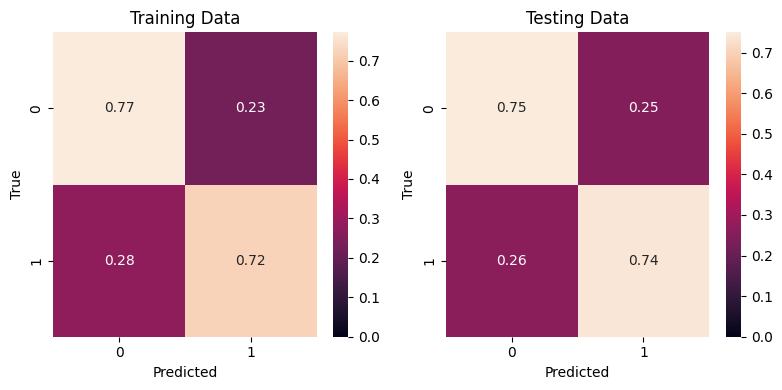

KNeighborsClassifier(n_neighbors=1)
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       100
           1       0.60      0.63      0.61        54

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



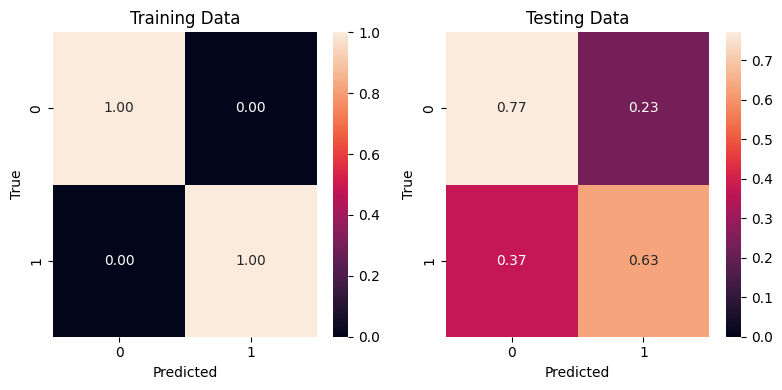

KNeighborsClassifier()
              precision    recall  f1-score   support

           0       0.80      0.66      0.73       100
           1       0.53      0.70      0.60        54

    accuracy                           0.68       154
   macro avg       0.67      0.68      0.66       154
weighted avg       0.71      0.68      0.68       154



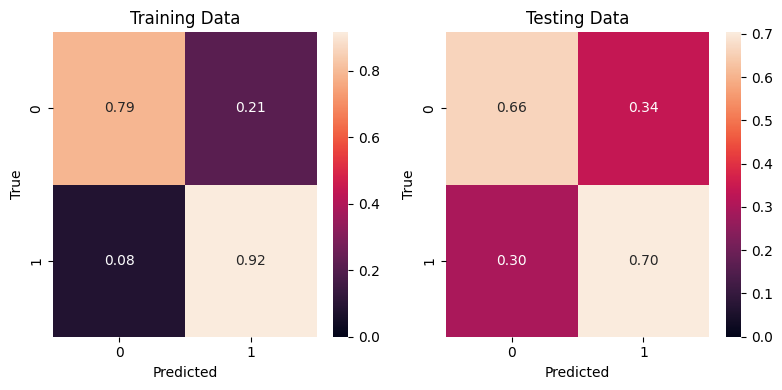

KNeighborsClassifier(n_neighbors=10)
              precision    recall  f1-score   support

           0       0.83      0.71      0.76       100
           1       0.57      0.72      0.64        54

    accuracy                           0.71       154
   macro avg       0.70      0.72      0.70       154
weighted avg       0.74      0.71      0.72       154



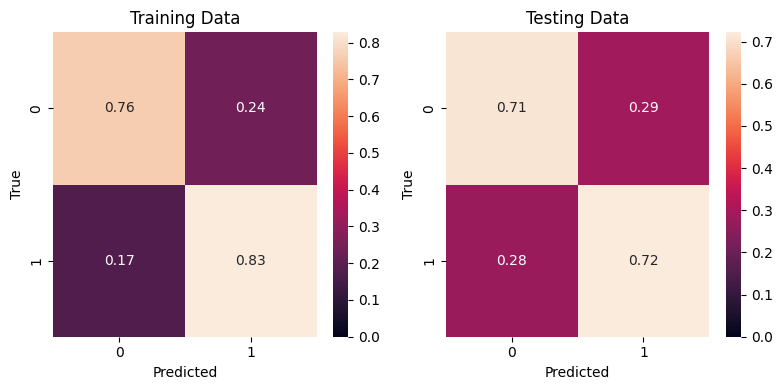

RandomForestClassifier(max_leaf_nodes=3, random_state=42)
              precision    recall  f1-score   support

           0       0.82      0.75      0.79       100
           1       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



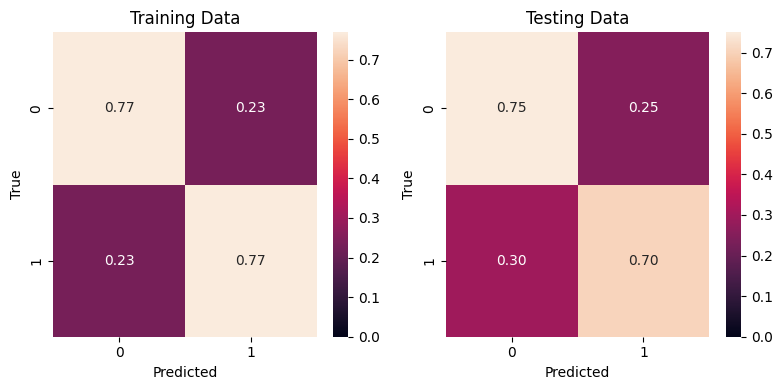

RandomForestClassifier(max_leaf_nodes=10, random_state=42)
              precision    recall  f1-score   support

           0       0.85      0.75      0.80       100
           1       0.62      0.76      0.68        54

    accuracy                           0.75       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.75      0.76       154



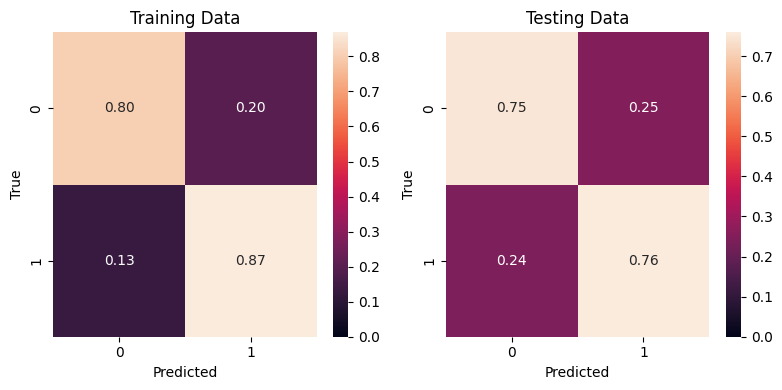

RandomForestClassifier(max_leaf_nodes=30, random_state=42)
              precision    recall  f1-score   support

           0       0.86      0.78      0.82       100
           1       0.65      0.76      0.70        54

    accuracy                           0.77       154
   macro avg       0.75      0.77      0.76       154
weighted avg       0.78      0.77      0.78       154



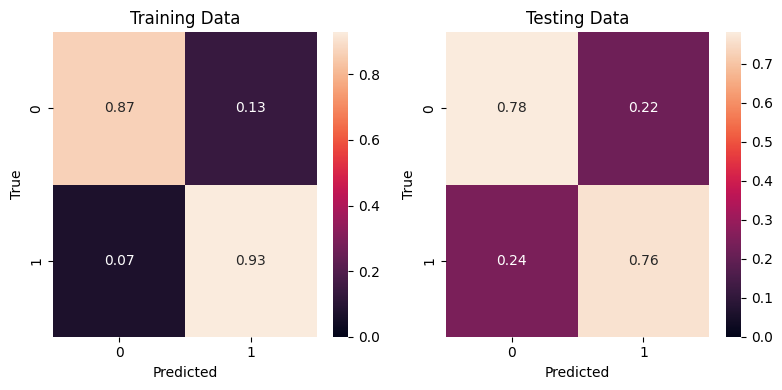

DecisionTreeClassifier(max_leaf_nodes=3, random_state=42)
              precision    recall  f1-score   support

           0       0.76      0.76      0.76       100
           1       0.56      0.56      0.56        54

    accuracy                           0.69       154
   macro avg       0.66      0.66      0.66       154
weighted avg       0.69      0.69      0.69       154



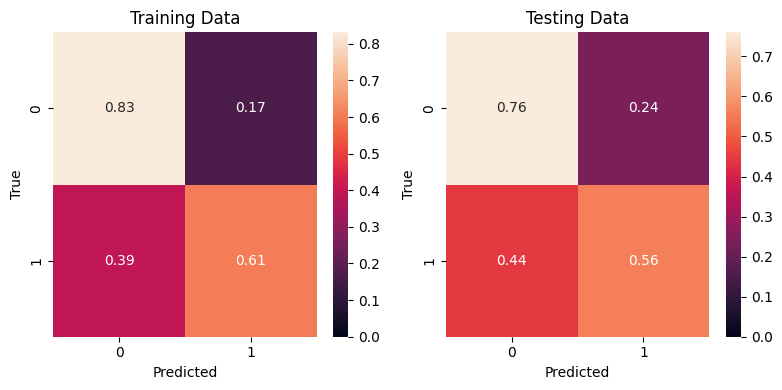

DecisionTreeClassifier(max_leaf_nodes=10, random_state=42)
              precision    recall  f1-score   support

           0       0.86      0.69      0.77       100
           1       0.58      0.80      0.67        54

    accuracy                           0.73       154
   macro avg       0.72      0.74      0.72       154
weighted avg       0.76      0.73      0.73       154



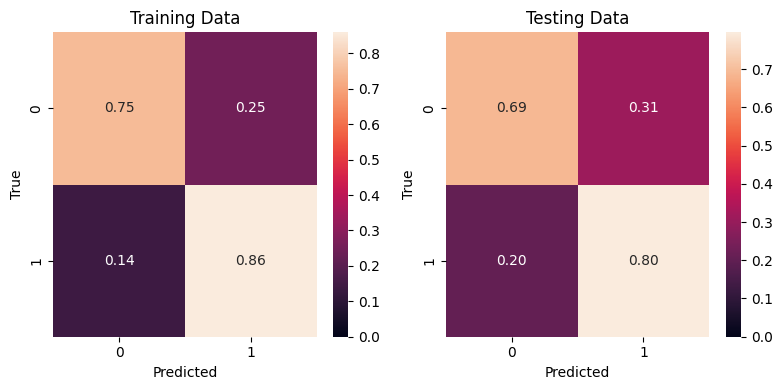

DecisionTreeClassifier(max_leaf_nodes=30, random_state=42)
              precision    recall  f1-score   support

           0       0.86      0.70      0.77       100
           1       0.59      0.80      0.68        54

    accuracy                           0.73       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.77      0.73      0.74       154



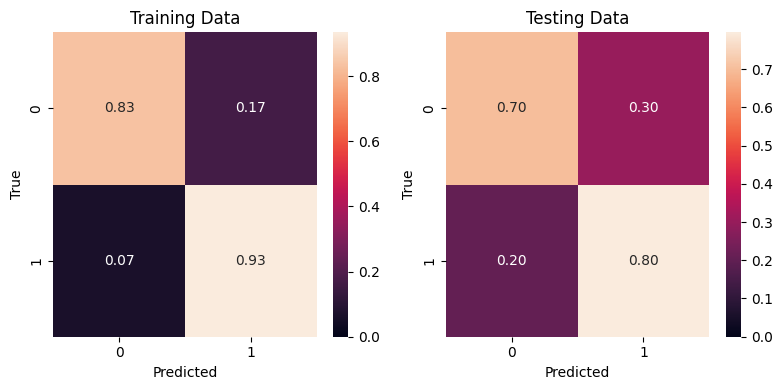

GradientBoostingClassifier(max_leaf_nodes=3, random_state=42)
              precision    recall  f1-score   support

           0       0.88      0.73      0.80       100
           1       0.62      0.81      0.70        54

    accuracy                           0.76       154
   macro avg       0.75      0.77      0.75       154
weighted avg       0.79      0.76      0.76       154



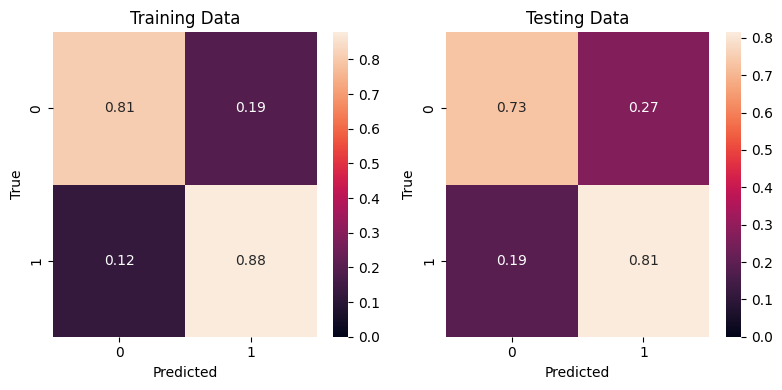

GradientBoostingClassifier(max_leaf_nodes=10, random_state=42)
              precision    recall  f1-score   support

           0       0.80      0.75      0.77       100
           1       0.58      0.65      0.61        54

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.69       154
weighted avg       0.72      0.71      0.72       154



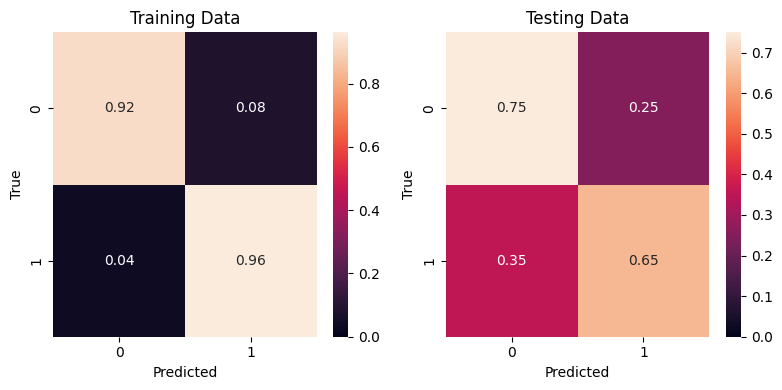

GradientBoostingClassifier(max_leaf_nodes=30, random_state=42)
              precision    recall  f1-score   support

           0       0.80      0.75      0.77       100
           1       0.58      0.65      0.61        54

    accuracy                           0.71       154
   macro avg       0.69      0.70      0.69       154
weighted avg       0.72      0.71      0.72       154



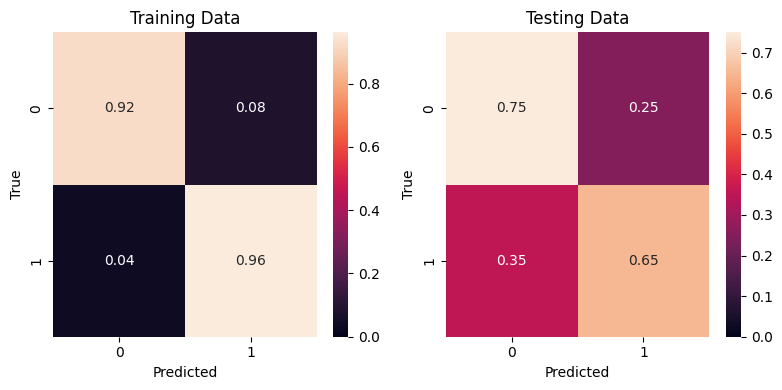

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=3, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

           0       0.89      0.74      0.81       100
           1       0.63      0.83      0.72        54

    accuracy                           0.77       154
   macro avg       0.76    

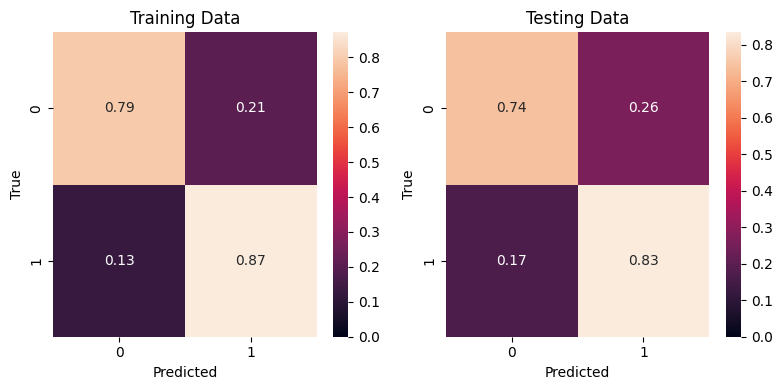

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=10, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

           0       0.84      0.76      0.80       100
           1       0.62      0.72      0.67        54

    accuracy                           0.75       154
   macro avg       0.73   

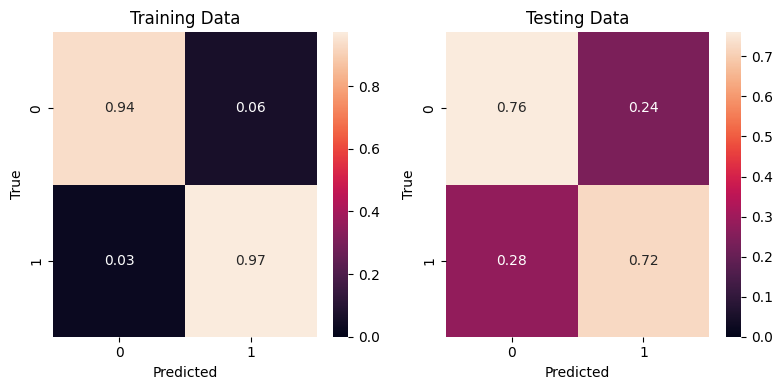

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=30, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)
              precision    recall  f1-score   support

           0       0.84      0.79      0.81       100
           1       0.65      0.72      0.68        54

    accuracy                           0.77       154
   macro avg       0.75   

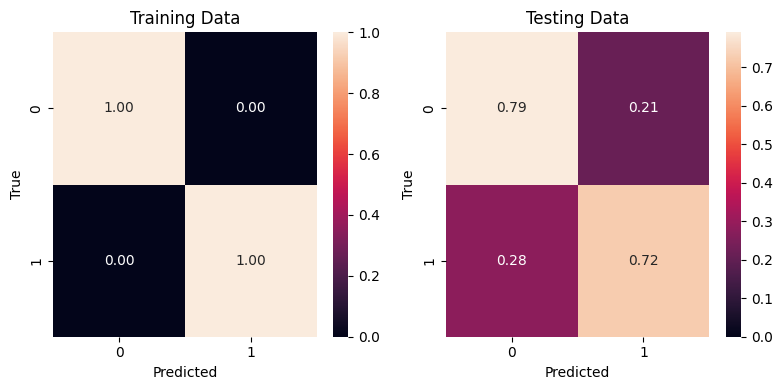

AdaBoostClassifier(learning_rate=0.1, n_estimators=100, random_state=42)
              precision    recall  f1-score   support

           0       0.82      0.70      0.76       100
           1       0.57      0.72      0.63        54

    accuracy                           0.71       154
   macro avg       0.69      0.71      0.70       154
weighted avg       0.73      0.71      0.71       154



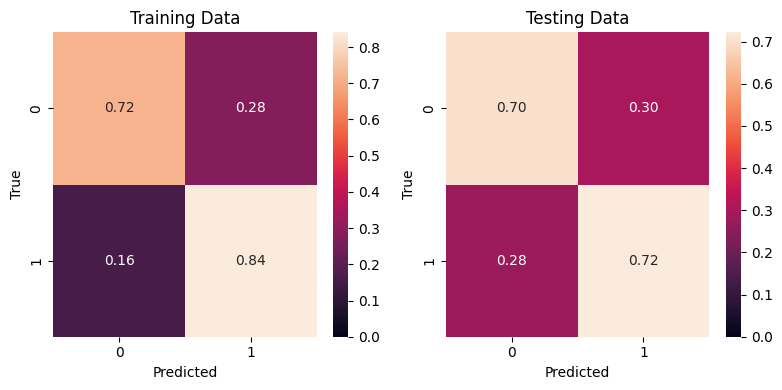

In [35]:
for m in models:
    # Train the model
    m.fit(X_tr_res, y_tr_res)

    print(m)

    # Generate predictions
    y_train_pred = m.predict(X_tr_res).astype(int)
    y_test_pred = m.predict(X_test_s).astype(int) # Corrected to use scaled test data

    # Print classification report
    print(classification_report(y_test, y_test_pred))

    # Compute confusion matrices
    conf_matrix_train = confusion_matrix(y_tr_res, y_train_pred).astype(float)
    conf_matrix_test = confusion_matrix(y_test, y_test_pred).astype(float)

    # Normalize confusion matrices
    for i in range(conf_matrix_train.shape[0]):
        conf_matrix_train[i, :] /= conf_matrix_train[i, :].sum()
        conf_matrix_test[i, :] /= conf_matrix_test[i, :].sum()

    # Create subplots for confusion matrices
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(8, 4))

    # Plot confusion matrix for training data
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='.2f', ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")

    # Plot confusion matrix for test data
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='.2f', ax=axes[1])
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")

    # Show the plots
    plt.tight_layout()
    plt.show()
# end

#KERAS Cross Validation

analyze the Keras Sequential model's performance on unseen data by creating multiple training and validation splits. This provides a much more robust and reliable estimate of your Keras model's generalization capability than a single train-validation split.


==================== Fold 1/10 ====================


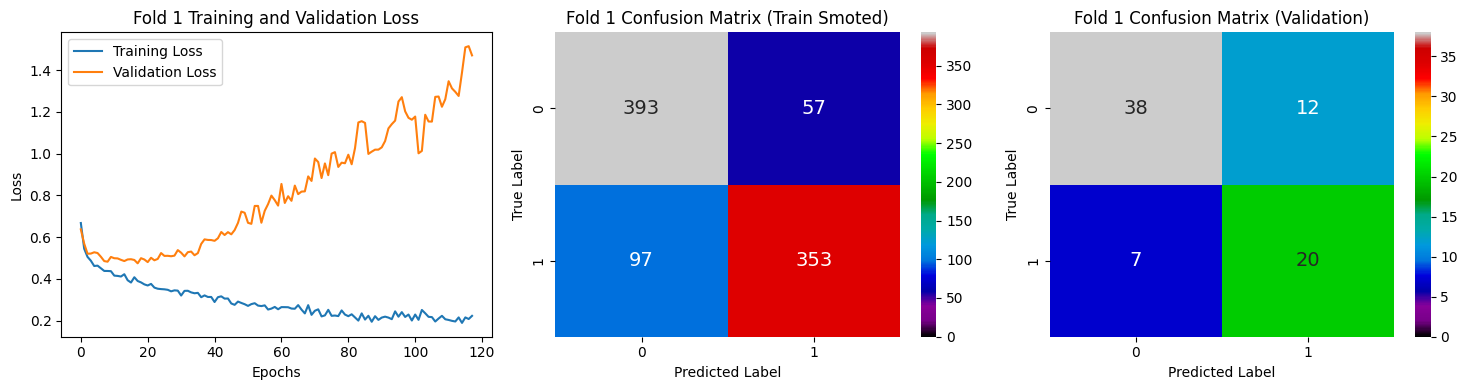

Classification Report (Validation Data - Fold 1):
              precision    recall  f1-score   support

           0       0.84      0.76      0.80        50
           1       0.62      0.74      0.68        27

    accuracy                           0.75        77
   macro avg       0.73      0.75      0.74        77
weighted avg       0.77      0.75      0.76        77


==================== Fold 2/10 ====================


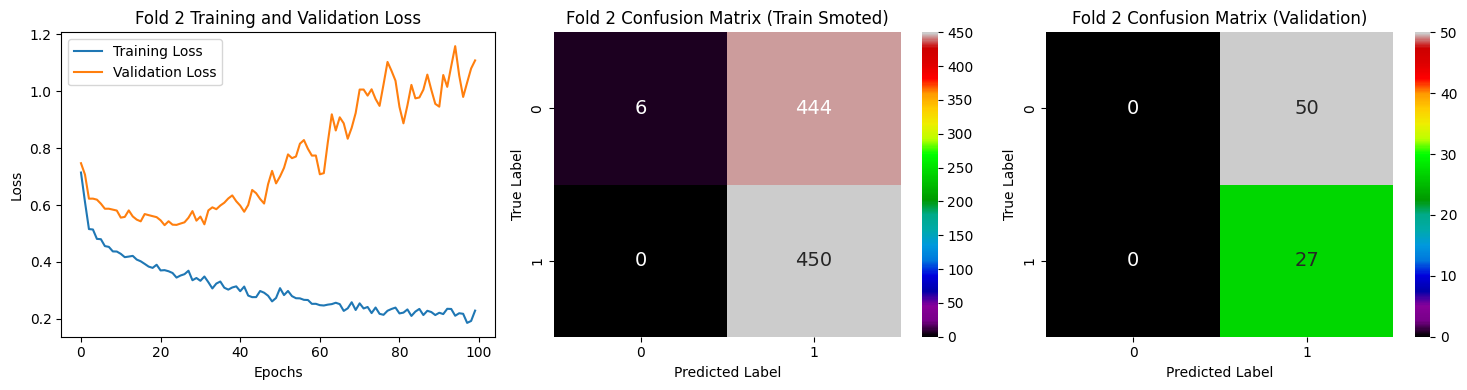

Classification Report (Validation Data - Fold 2):
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        50
           1       0.35      1.00      0.52        27

    accuracy                           0.35        77
   macro avg       0.18      0.50      0.26        77
weighted avg       0.12      0.35      0.18        77


==================== Fold 3/10 ====================


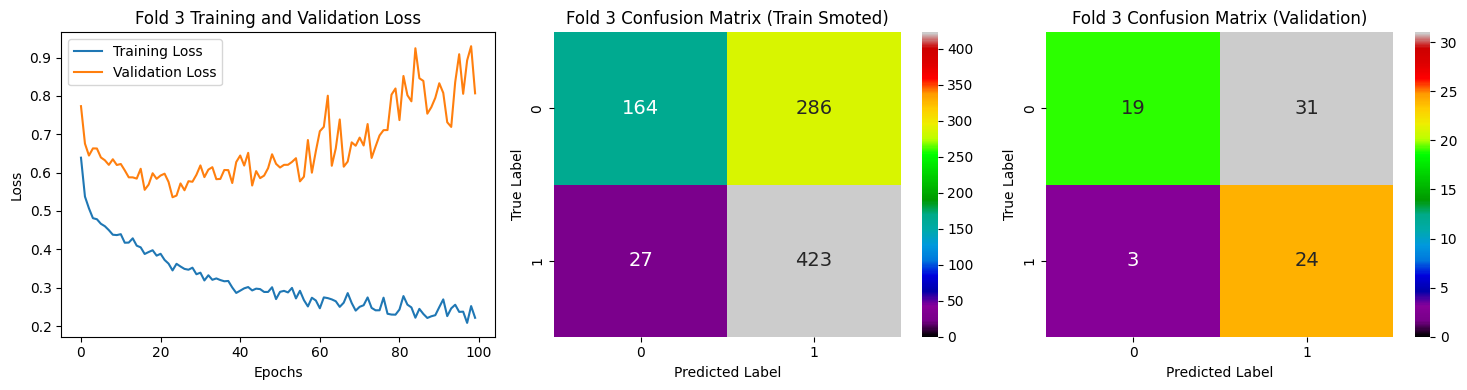

Classification Report (Validation Data - Fold 3):
              precision    recall  f1-score   support

           0       0.86      0.38      0.53        50
           1       0.44      0.89      0.59        27

    accuracy                           0.56        77
   macro avg       0.65      0.63      0.56        77
weighted avg       0.71      0.56      0.55        77


==================== Fold 4/10 ====================


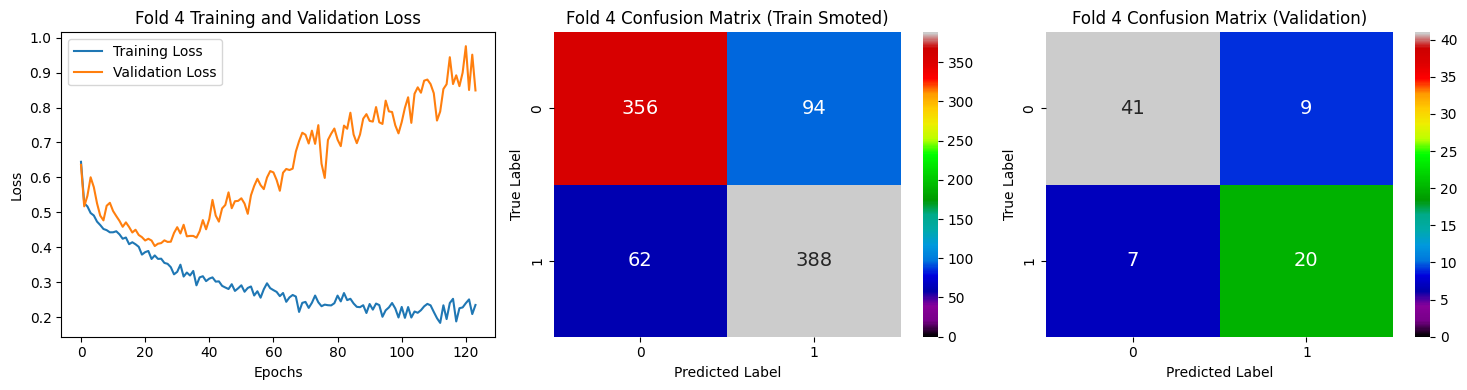

Classification Report (Validation Data - Fold 4):
              precision    recall  f1-score   support

           0       0.85      0.82      0.84        50
           1       0.69      0.74      0.71        27

    accuracy                           0.79        77
   macro avg       0.77      0.78      0.78        77
weighted avg       0.80      0.79      0.79        77


==================== Fold 5/10 ====================


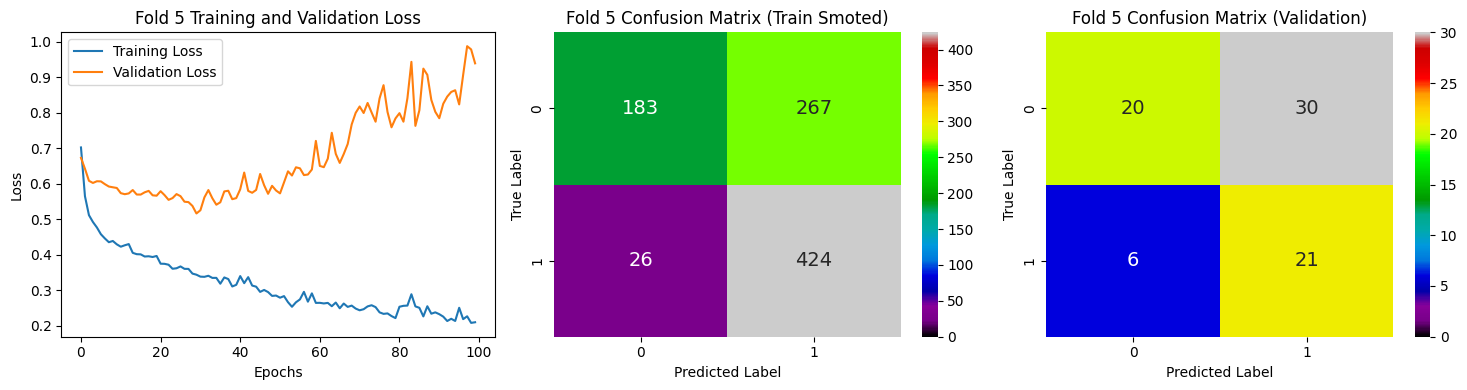

Classification Report (Validation Data - Fold 5):
              precision    recall  f1-score   support

           0       0.77      0.40      0.53        50
           1       0.41      0.78      0.54        27

    accuracy                           0.53        77
   macro avg       0.59      0.59      0.53        77
weighted avg       0.64      0.53      0.53        77


==================== Fold 6/10 ====================


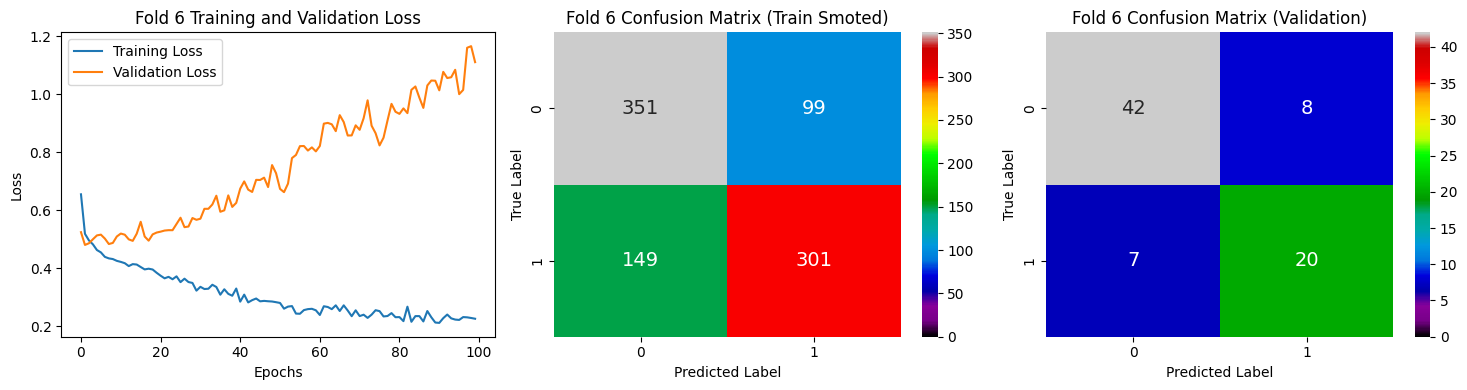

Classification Report (Validation Data - Fold 6):
              precision    recall  f1-score   support

           0       0.86      0.84      0.85        50
           1       0.71      0.74      0.73        27

    accuracy                           0.81        77
   macro avg       0.79      0.79      0.79        77
weighted avg       0.81      0.81      0.81        77


==================== Fold 7/10 ====================


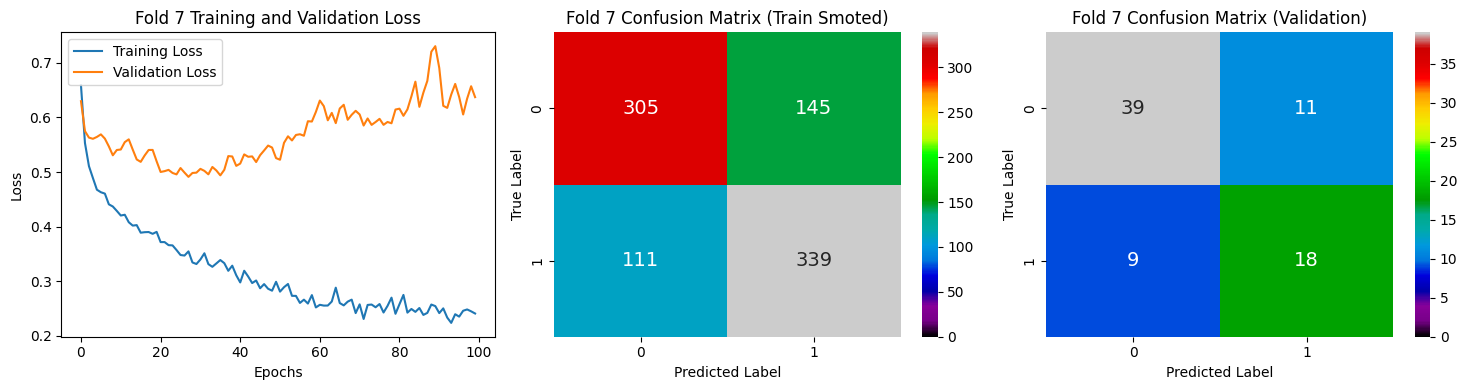

Classification Report (Validation Data - Fold 7):
              precision    recall  f1-score   support

           0       0.81      0.78      0.80        50
           1       0.62      0.67      0.64        27

    accuracy                           0.74        77
   macro avg       0.72      0.72      0.72        77
weighted avg       0.75      0.74      0.74        77


==================== Fold 8/10 ====================


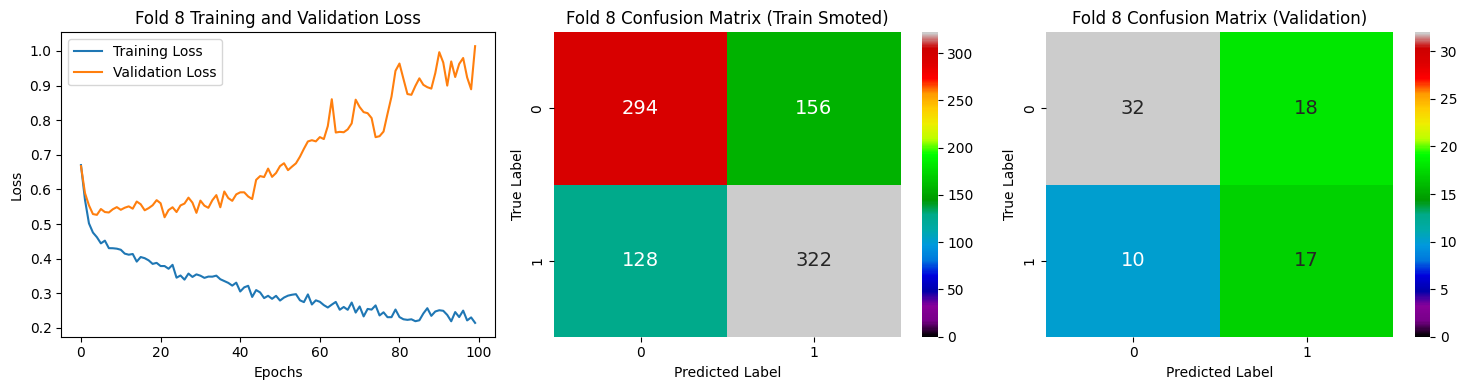

Classification Report (Validation Data - Fold 8):
              precision    recall  f1-score   support

           0       0.76      0.64      0.70        50
           1       0.49      0.63      0.55        27

    accuracy                           0.64        77
   macro avg       0.62      0.63      0.62        77
weighted avg       0.67      0.64      0.64        77


==================== Fold 9/10 ====================


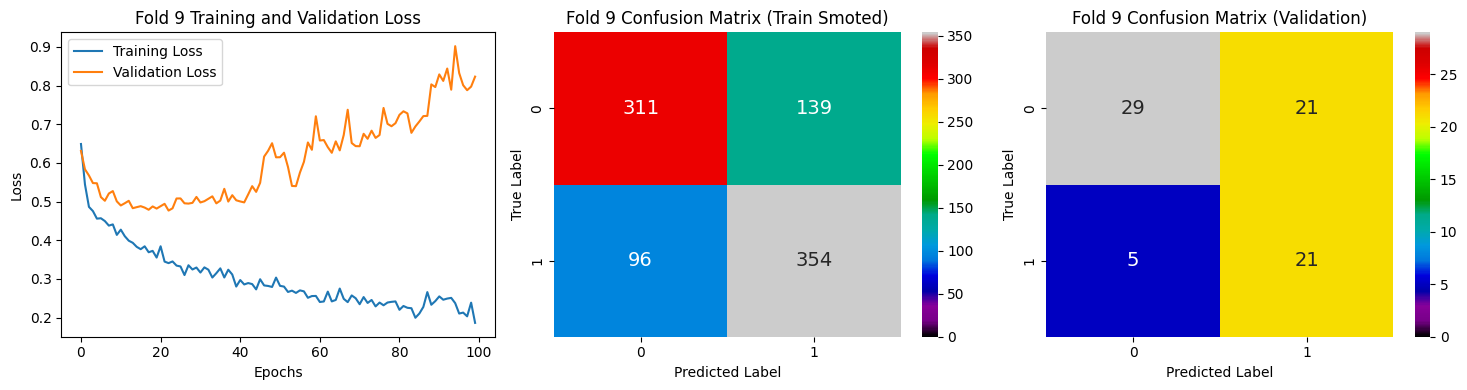

Classification Report (Validation Data - Fold 9):
              precision    recall  f1-score   support

           0       0.85      0.58      0.69        50
           1       0.50      0.81      0.62        26

    accuracy                           0.66        76
   macro avg       0.68      0.69      0.65        76
weighted avg       0.73      0.66      0.67        76


==================== Fold 10/10 ====================


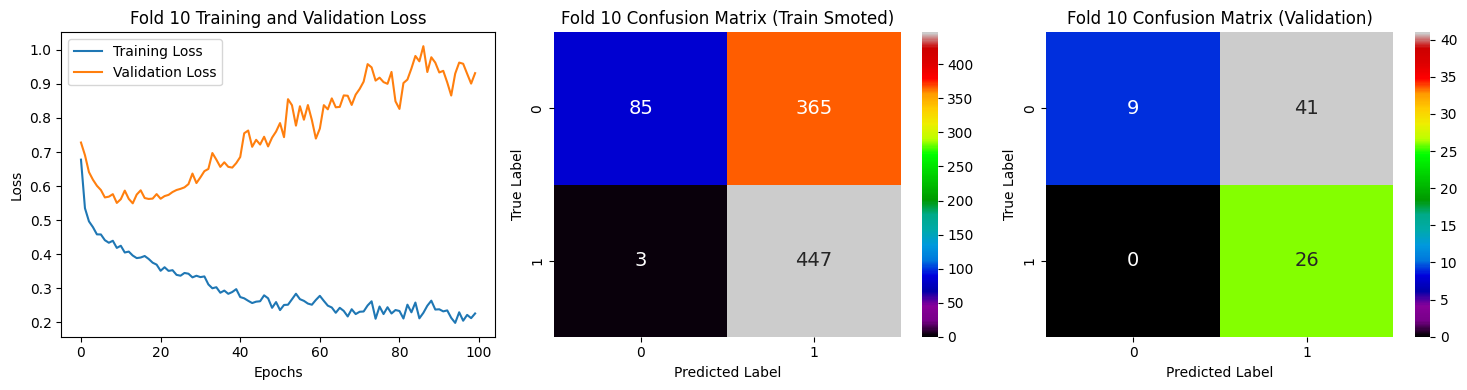

Classification Report (Validation Data - Fold 10):
              precision    recall  f1-score   support

           0       1.00      0.18      0.31        50
           1       0.39      1.00      0.56        26

    accuracy                           0.46        76
   macro avg       0.69      0.59      0.43        76
weighted avg       0.79      0.46      0.39        76


==================== Cross-Validation Summary ====================
Average Validation Accuracy across 10 folds: 0.6287
Average Macro F1-score across 10 folds: 0.6079
Standard Deviation of Validation Accuracy: 0.1437
Standard Deviation of Macro F1-score: 0.1590


In [34]:
import tensorflow as tf
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd # Ensure pandas is imported for .iloc

splits = 10 # Number of folds

dropout_rate = 0.1
n_classes = np.unique(y).shape[0] # Number of unique classes in the target variable

learning_rate = 0.01

# Early stopping callback to prevent overfitting and restore best weights
early_stopping = EarlyStopping(
    monitor='val_loss', # Monitor validation loss
    patience=100,         # Stop if validation loss doesn't improve for 100 epochs
    restore_best_weights=True # Restore the model weights from the epoch with the best validation loss
)

# Initialize Stratified K-Fold to maintain class proportions in each split
kf = StratifiedKFold(n_splits=splits, shuffle=True, random_state=42) # Added random_state for reproducibility

fold_results = [] # List to store results from each fold

# Iterate through each fold generated by StratifiedKFold
for fold, (train_index, val_index) in enumerate(kf.split(X, y)):
    tf.keras.backend.clear_session() # Clear Keras session for a fresh model in each fold

    print(f"\n{'='*20} Fold {fold+1}/{splits} {'='*20}")

    # Split data for the current fold using the indices from StratifiedKFold
    X_train_fold, X_val_fold = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val_fold = y.iloc[train_index], y.iloc[val_index]

    # Initialize StandardScaler and SMOTE for each fold to prevent data leakage
    std_scaler_fold = StandardScaler() # Scales features to have zero mean and unit variance
    smote_fold = SMOTE(sampling_strategy='auto', k_neighbors=20, random_state=42) # Over-samples minority class (k_neighbors=20 from original Keras cell)

    # 1. Scale the data: fit on training data of current fold, then transform both training and validation data
    X_train_scaled = std_scaler_fold.fit_transform(X_train_fold)
    X_val_scaled = std_scaler_fold.transform(X_val_fold)

    # 2. Apply SMOTE only to the *scaled* training data of the current fold to balance classes
    X_train_smoted, y_train_smoted = smote_fold.fit_resample(X_train_scaled, y_train_fold)

    # Build Keras model (architecture identical to cell VmAjjxvZthrC)
    model = Sequential([
        Input(shape=X.shape[1:]), # Input shape is the number of original features (8 in this case)
        Dense(20, activation='relu'), # First hidden layer with ReLU activation
        BatchNormalization(), # Normalizes activations of previous layer
        Dropout(dropout_rate), # Randomly sets a fraction of input units to 0 at each update during training
        Dense(20, activation='relu'), # Second hidden layer with ReLU activation
        Dense(20, activation='relu'), # Third hidden layer with ReLU activation
        Dense(n_classes, activation='softmax'), # Output layer with softmax for multi-class probability distribution
    ])

    # Define the optimizer with a custom learning rate
    optimizer = Adam(learning_rate=learning_rate)

    # Compile model with appropriate loss function and metrics for binary classification
    model.compile(
        optimizer=optimizer,
        loss='sparse_categorical_crossentropy', # Appropriate for integer labels (0 or 1) and softmax output
        metrics=['accuracy'] # Monitor accuracy during training
    )

    # Train the model on the SMOTEd and scaled training data
    history = model.fit(
        X_train_smoted, y_train_smoted,
        epochs=1000, # Maximum number of epochs, early stopping will stop training if no improvement
        batch_size=256,
        validation_data=(X_val_scaled, y_val_fold), # Evaluate on scaled validation data
        callbacks=[early_stopping],
        verbose=0, # Set to 0 to suppress output for each epoch, only print fold summary
    )

    # --- Evaluate Model for Current Fold --- (on best weights due to EarlyStopping)
    # Get predictions for training and validation data
    y_train_pred_probs = model.predict(X_train_smoted, verbose=0)
    y_train_pred = np.argmax(y_train_pred_probs, axis=1)

    y_val_pred_probs = model.predict(X_val_scaled, verbose=0)
    y_val_pred  = np.argmax(y_val_pred_probs, axis=1)

    # Compute confusion matrices for both training and validation sets
    cm_train = confusion_matrix(y_train_smoted, y_train_pred)
    cm_val = confusion_matrix(y_val_fold, y_val_pred)

    # Generate classification report for validation data to get detailed metrics
    report_val = classification_report(y_val_fold, y_val_pred, output_dict=True, zero_division=0)
    fold_accuracy = report_val['accuracy']
    fold_f1_macro = report_val['macro avg']['f1-score']

    # Store results for this fold
    fold_results.append({
        'fold': fold + 1,
        'accuracy': fold_accuracy,
        'f1_macro': fold_f1_macro,
        'train_history': history,
        'cm_train': cm_train,
        'cm_val': cm_val,
        'report_val': report_val
    })

    # Plot results for this individual fold
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # Left subplot: Training and Validation Loss over epochs
    axes[0].plot(history.history['loss'], label='Training Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title(f'Fold {fold+1} Training and Validation Loss')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    # Middle subplot: Confusion Matrix for the SMOTEd training data
    sns.heatmap(cm_train, annot=True, fmt='d', ax=axes[1], vmin=0, annot_kws={"size": 14}, cmap='nipy_spectral')
    axes[1].set_title(f'Fold {fold+1} Confusion Matrix (Train Smoted)')
    axes[1].set_xlabel('Predicted Label')
    axes[1].set_ylabel('True Label')

    # Right subplot: Confusion Matrix for the validation data of the current fold
    sns.heatmap(cm_val, annot=True, fmt='d', ax=axes[2], vmin=0, annot_kws={"size": 14}, cmap='nipy_spectral')
    axes[2].set_title(f'Fold {fold+1} Confusion Matrix (Validation)')
    axes[2].set_xlabel('Predicted Label')
    axes[2].set_ylabel('True Label')

    plt.tight_layout()
    plt.show()

    print(f"Classification Report (Validation Data - Fold {fold+1}):")
    print(classification_report(y_val_fold, y_val_pred, zero_division=0))

# --- Summarize all folds after the loop completes ---
print(f"\n{'='*20} Cross-Validation Summary {'='*20}")
# Calculate average accuracy and F1-score across all folds
avg_accuracy = np.mean([res['accuracy'] for res in fold_results])
avg_f1_macro = np.mean([res['f1_macro'] for res in fold_results])
print(f"Average Validation Accuracy across {splits} folds: {avg_accuracy:.4f}")
print(f"Average Macro F1-score across {splits} folds: {avg_f1_macro:.4f}")

# Optional: Display standard deviation for a better understanding of variability
std_accuracy = np.std([res['accuracy'] for res in fold_results])
std_f1_macro = np.std([res['f1_macro'] for res in fold_results])
print(f"Standard Deviation of Validation Accuracy: {std_accuracy:.4f}")
print(f"Standard Deviation of Macro F1-score: {std_f1_macro:.4f}")

### Comparison: Keras CV vs. Traditional ML Models

In [37]:
keras_cv_metrics = {
    'Model': 'Keras CV (Avg over 10 folds)',
    'AUPRC': np.nan, # Not directly calculated in the CV summary
    'AUROC': np.nan, # Not directly calculated in the CV summary
    'MCC': np.nan,   # Not directly calculated in the CV summary
    'F1': avg_f1_macro,
    'Accuracy': avg_accuracy # Adding accuracy for completeness
}

# Convert to DataFrame
keras_cv_df = pd.DataFrame([keras_cv_metrics])

# Ensure results_df has an 'Accuracy' column for consistent concatenation.
# For existing models, if 'Accuracy' is not present, it would be good to add it,
# but for this comparison, we'll assume the primary comparison is F1 and AUPRC.
# We'll just add accuracy to the Keras row for now.

# Let's align columns for concatenation.
# We'll re-create results_df from the existing 'results' list to ensure consistency and add Accuracy if needed.
# Since `results` list was used to create `results_df` in `_p8_7dJ_qy2d`, and that cell was executed,
# `results_df` should be available. We will add an 'Accuracy' column if it's missing.

# Assuming results_df from cell _p8_7dJ_qy2d is available
# If results_df doesn't have an 'Accuracy' column from previous runs, we'll create it with NaNs
if 'Accuracy' not in results_df.columns:
    results_df['Accuracy'] = np.nan

# Select and reorder columns for concatenation to match `keras_cv_df`
# Only keep common columns and F1, AUPRC, AUROC, MCC for main comparison
common_cols = ['Model', 'AUPRC', 'AUROC', 'MCC', 'F1']
combined_df = pd.concat([results_df[common_cols], keras_cv_df[common_cols]], ignore_index=True)

print("\n=== Combined Model Comparison (Keras CV vs. Traditional ML, sorted by F1) ===")
# Sort by F1-score for a clear comparison
display(combined_df.sort_values('F1', ascending=False).reset_index(drop=True).fillna('N/A'))


=== Combined Model Comparison (Keras CV vs. Traditional ML, sorted by F1) ===


,Model,AUPRC,AUROC,MCC,F1
0,XGBClassifier(leaves=3),0.674041,0.823333,0.559017,0.725806
1,RandomForestClassifier(leaves=30),0.722749,0.828889,0.531687,0.709677
2,RandomForestClassifier(leaves=3),0.705587,0.82537,0.524954,0.704918
3,DecisionTreeClassifier(leaves=10),0.668183,0.818796,0.499484,0.692308
4,AdaBoostClassifier(leaves=N/A),0.705732,0.835741,0.499484,0.692308
5,LogisticRegression(leaves=N/A),0.696726,0.822593,0.491046,0.683333
6,RandomForestClassifier(leaves=10),0.728827,0.832778,0.484204,0.682540
7,GradientBoostingClassifier(leaves=3),0.694132,0.818889,0.463548,0.666667
8,DecisionTreeClassifier(leaves=30),0.591829,0.786667,0.468008,0.666667
9,XGBClassifier(leaves=10),0.706364,0.823519,0.457227,0.661017
